# Calories Regression — LifeSnaps Dataset (19 Selected Features)

Predict daily calorie burn from Fitbit data using the LifeSnaps dataset.

> **This notebook is identical to `01_calories_regression.ipynb` but uses only the
> **19 pre-selected features** (XGBoost cumulative-95% importance from notebook 01)
> instead of all 52 engineered features.
>
> Feature selection rationale: dropping 33 low-importance features costs only ~+2 kcal MAE
> while reducing model complexity and data-collection requirements.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate, KFold, GroupKFold
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
import lightgbm as lgb

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '/Users/thunthita/VISTEC/LifeSnaps/rais_anonymized/csv_rais_anonymized/daily_fitbit_sema_df_unprocessed.csv'
import sys, os; sys.path.insert(0, os.path.abspath(".."))
from lifesnaps_lib.preprocessing import PerUserMedianImputer


## 1. Load & Inspect Data

In [2]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=['date'])
print(f'Raw shape: {df_raw.shape}')
print(f'Users: {df_raw["id"].nunique()}')
print(f'Date range: {df_raw["date"].min()} to {df_raw["date"].max()}')
df_raw.head(3)

Raw shape: (7410, 63)
Users: 71
Date range: 2021-04-08 00:00:00 to 2022-01-22 00:00:00


,Unnamed: 0,id,date,nightly_temperature,nremhr,rmssd,spo2,full_sleep_breathing_rate,stress_score,sleep_points_percentage,...,TENSE/ANXIOUS,TIRED,ENTERTAINMENT,GYM,HOME,HOME_OFFICE,OTHER,OUTDOORS,TRANSIT,WORK/SCHOOL
0,0,621e2e8e67b776a24055b564,2021-05-24,34.137687,57.432,89.603,NaN,14.8,78.0,0.833333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,621e2e8e67b776a24055b564,2021-05-25,33.794544,57.681,94.303,NaN,15.8,80.0,0.833333,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,2,621e2e8e67b776a24055b564,2021-05-26,34.611011,57.481,119.212,NaN,14.6,84.0,0.966667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [3]:
# Drop rows with missing or implausible calories (< 500 kcal likely means incomplete day)
df = df_raw.dropna(subset=['calories']).copy()
df = df[df['calories'] >= 500].copy()
df = df.sort_values(['id', 'date']).reset_index(drop=True)

print(f'After filtering: {df.shape}')
print(f'Users: {df["id"].nunique()}')

rows_per_user = df.groupby('id').size()
print(f'\nRows per user: min={rows_per_user.min()}, median={rows_per_user.median():.0f}, max={rows_per_user.max()}')

After filtering: (6638, 63)
Users: 71

Rows per user: min=58, median=81, max=243


In [4]:
# Missing value overview for key columns (19 selected features)
key_cols = ['calories', 'steps', 'distance', 'very_active_minutes', 'moderately_active_minutes',
            'lightly_active_minutes', 'bpm', 'resting_hr', 'nremhr', 'rmssd',
            'filteredDemographicVO2Max', 'nightly_temperature', 'daily_temperature_variation',
            'bmi', 'ALERT', 'TIRED']

missing = (df[key_cols].isnull().sum() / len(df) * 100).round(1)
print('Missing % for key columns:')
print(missing.to_string())


Missing % for key columns:
calories                        0.0
steps                          28.1
distance                       28.1
very_active_minutes             0.0
moderately_active_minutes       0.0
lightly_active_minutes          0.0
bpm                            27.6
resting_hr                     33.5
nremhr                         62.8
rmssd                          62.8
filteredDemographicVO2Max      27.9
nightly_temperature            49.4
daily_temperature_variation    50.3
bmi                             8.3
ALERT                          66.2
TIRED                          66.2


## 2. Feature Engineering

In [5]:
# ── Time features ──
df['DayOfWeek'] = df['date'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# ── Activity features ──
df['TotalActiveMinutes'] = (df['very_active_minutes'] + df['moderately_active_minutes'] + df['lightly_active_minutes'])
df['ActiveRatio'] = df['TotalActiveMinutes'] / (df['TotalActiveMinutes'] + df['sedentary_minutes'] + 1e-9)
df['StepsPerActiveMin'] = np.where(
    df['TotalActiveMinutes'] > 0,
    df['steps'] / df['TotalActiveMinutes'],
    0
)

# ── HR zone features ──
df['hr_zone_cardio'] = df['minutes_in_default_zone_2']

# ── Ensure all feature columns are numeric ──
# 19 pre-selected features (XGBoost cumulative-95% importance, notebook 01)
feature_cols = [
    # ── Activity (raw) ──
    'steps', 'distance', 'very_active_minutes', 'moderately_active_minutes', 'lightly_active_minutes',
    # ── Activity (engineered) ──
    'TotalActiveMinutes', 'ActiveRatio', 'StepsPerActiveMin',
    # ── Heart rate ──
    'bpm', 'resting_hr', 'hr_zone_cardio',
    # ── HRV / advanced Fitbit ──
    'nremhr', 'rmssd', 'filteredDemographicVO2Max',
    # ── Skin temperature ──
    'nightly_temperature', 'daily_temperature_variation',
    # ── Demographics ──
    'bmi',
    # ── Mood (SEMA app, ~66% missing) ──
    'ALERT', 'TIRED',
]

# Cast all feature cols to numeric (safety net)
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

target = 'calories'

X = df[['id'] + feature_cols]
y = df[target]
groups = df['id']

print(f'Features: {len(feature_cols)} | X shape: {X.shape}')
all_features = feature_cols


Features: 19 | X shape: (6638, 20)


## 3. Target Distribution

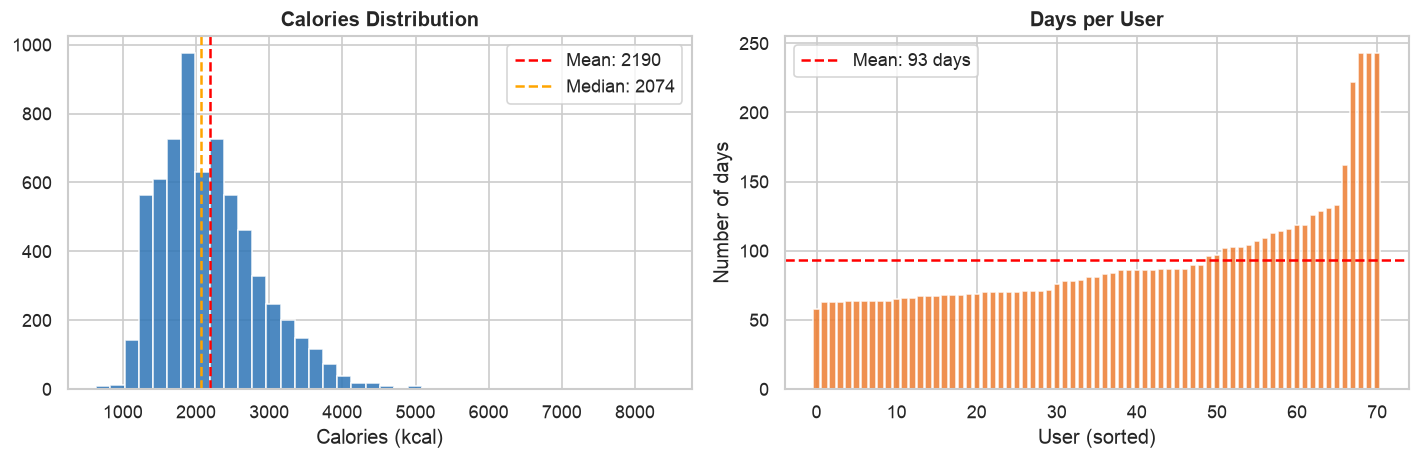

Total rows: 6638 | Users: 71
Calories — mean: 2190, std: 694, min: 635, max: 8387


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=40, edgecolor='white', color='#2E75B6', alpha=0.85)
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean: {y.mean():.0f}')
axes[0].axvline(y.median(), color='orange', linestyle='--', label=f'Median: {y.median():.0f}')
axes[0].set_title('Calories Distribution', fontweight='bold')
axes[0].set_xlabel('Calories (kcal)')
axes[0].legend()

# Rows per user
rows_per_user = df.groupby('id').size().sort_values()
axes[1].bar(range(len(rows_per_user)), rows_per_user.values, color='#ED7D31', alpha=0.85)
axes[1].axhline(rows_per_user.mean(), color='red', linestyle='--', label=f'Mean: {rows_per_user.mean():.0f} days')
axes[1].set_title('Days per User', fontweight='bold')
axes[1].set_xlabel('User (sorted)')
axes[1].set_ylabel('Number of days')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Total rows: {len(df)} | Users: {df["id"].nunique()}')
print(f'Calories — mean: {y.mean():.0f}, std: {y.std():.0f}, min: {y.min():.0f}, max: {y.max():.0f}')

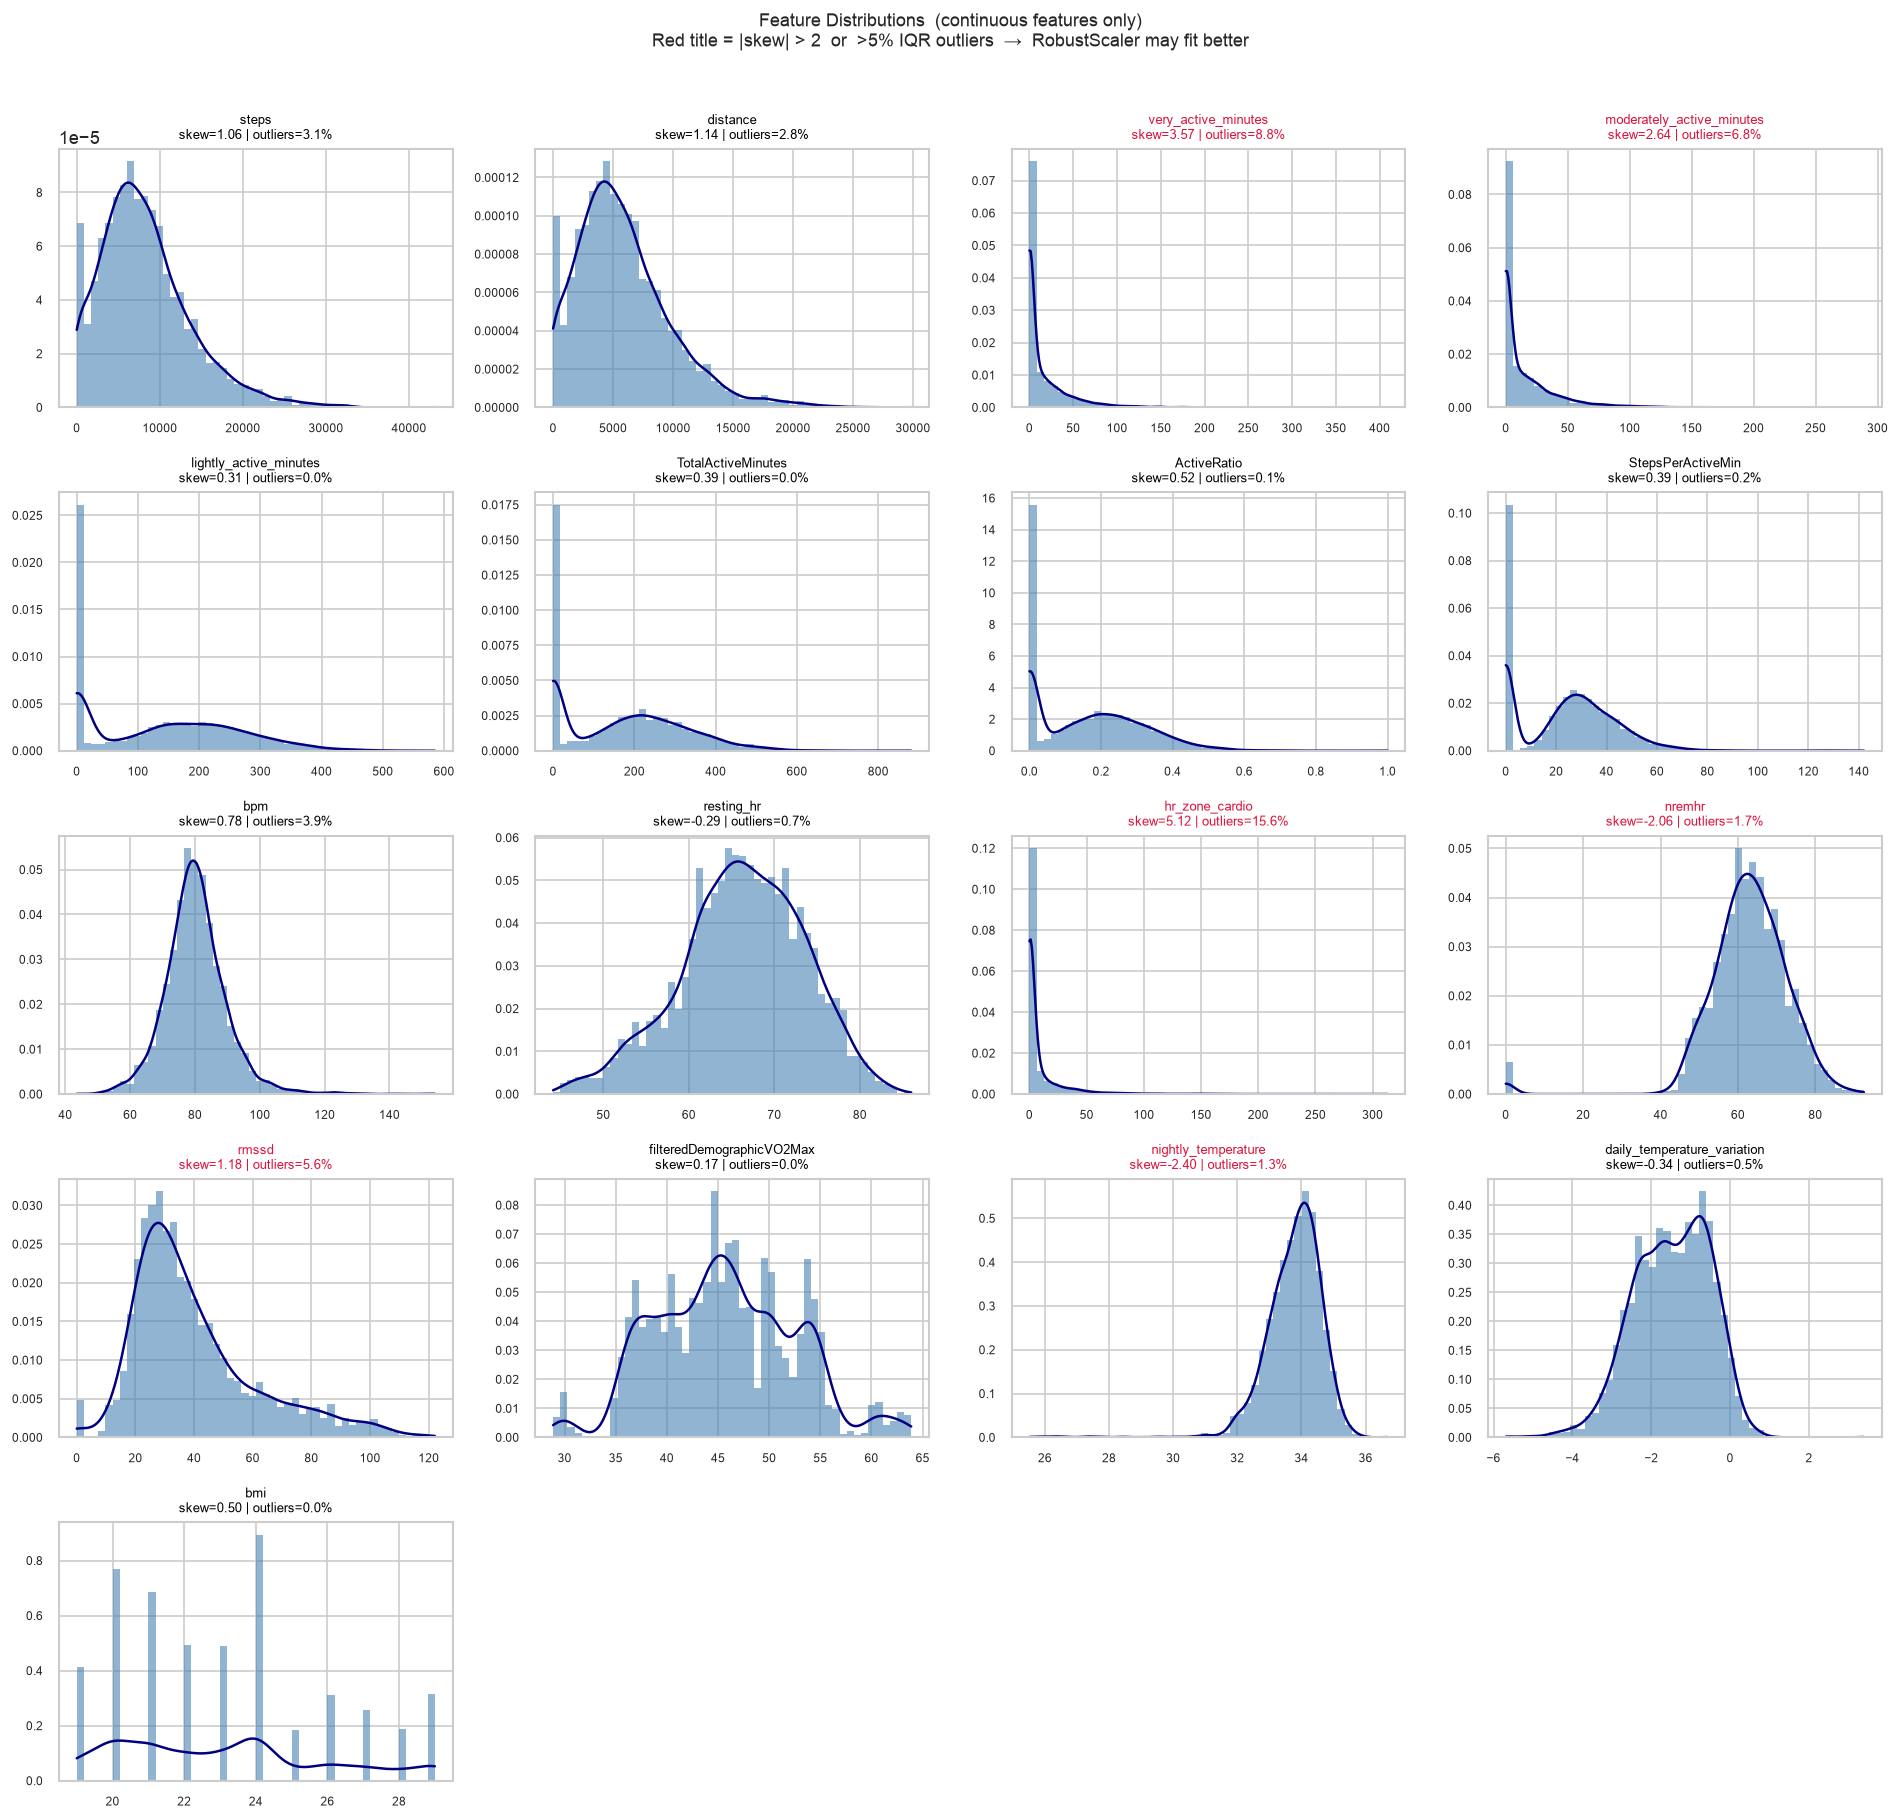

                    feature  skewness  outlier_%    recommendation
             hr_zone_cardio      5.12       15.6      RobustScaler
        very_active_minutes      3.57        8.8      RobustScaler
  moderately_active_minutes      2.64        6.8      RobustScaler
                      rmssd      1.18        5.6      RobustScaler
                        bpm      0.78        3.9 StandardScaler OK
                      steps      1.06        3.1 StandardScaler OK
                   distance      1.14        2.8 StandardScaler OK
                     nremhr     -2.06        1.7      RobustScaler
        nightly_temperature     -2.40        1.3      RobustScaler
                 resting_hr     -0.29        0.7 StandardScaler OK
daily_temperature_variation     -0.34        0.5 StandardScaler OK
          StepsPerActiveMin      0.39        0.2 StandardScaler OK
                ActiveRatio      0.52        0.1 StandardScaler OK
         TotalActiveMinutes      0.39        0.0 StandardScale

In [7]:
# ── 16) Feature distribution plots (outlier check → StandardScaler vs RobustScaler) ──
import matplotlib.pyplot as plt
from scipy import stats

# Exclude binary/categorical features
skip_cols = ['ALERT', 'TIRED']  # binary / categorical among the 19 features

plot_cols = [c for c in feature_cols if c not in skip_cols]

ncols = 4
nrows = -(-len(plot_cols) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    data = df[col].dropna()

    skew = data.skew()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    pct_outliers = n_outliers / len(data) * 100

    ax.hist(data, bins=50, color='steelblue', alpha=0.6, density=True, edgecolor='none')
    try:
        kde_x = np.linspace(data.min(), data.max(), 300)
        kde = stats.gaussian_kde(data)
        ax.plot(kde_x, kde(kde_x), color='navy', lw=1.5)
    except Exception:
        pass

    # Red title = high skew or many outliers → RobustScaler likely better
    bad = abs(skew) > 2 or pct_outliers > 5
    ax.set_title(f'{col}\nskew={skew:.2f} | outliers={pct_outliers:.1f}%',
                 fontsize=8, color='crimson' if bad else 'black')
    ax.tick_params(labelsize=7)

# Hide unused axes
for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Feature Distributions  (continuous features only)\n'
    'Red title = |skew| > 2  or  >5% IQR outliers  →  RobustScaler may fit better',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

# ── Summary table ──
summary = []
for col in plot_cols:
    data = df[col].dropna()
    skew = data.skew()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    pct_out = n_out / len(data) * 100
    rec = 'RobustScaler' if (abs(skew) > 2 or pct_out > 5) else 'StandardScaler OK'
    summary.append({'feature': col, 'skewness': round(skew, 2),
                    'outlier_%': round(pct_out, 1), 'recommendation': rec})

dist_summary_df = pd.DataFrame(summary).sort_values('outlier_%', ascending=False)
print(dist_summary_df.to_string(index=False))


In [ ]:
# ── StandardScaler vs RobustScaler — Ridge & Lasso only (GroupKFold) ──
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GroupKFold

gkf_local = GroupKFold(n_splits=3)
from sklearn.linear_model import ElasticNet, Ridge, Lasso

scaler_results = []

for scaler_name, scaler_obj in [('StandardScaler', StandardScaler()), ('RobustScaler', RobustScaler())]:
    for model_name, model_obj in [('Ridge', Ridge(alpha=1.0)), ('Lasso', Lasso(alpha=1.0, max_iter=5000)), ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000))]:
        pipe = Pipeline([
            ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
            ('scaler',  scaler_obj),
            ('model',   model_obj),
        ])
        maes, rmses, r2s = [], [], []
        for train_idx, test_idx in gkf_local.split(X, y, groups):
            pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
            y_pred = pipe.predict(X.iloc[test_idx])
            maes.append(mean_absolute_error(y.iloc[test_idx], y_pred))
            rmses.append(mean_squared_error(y.iloc[test_idx], y_pred) ** 0.5)
            r2s.append(r2_score(y.iloc[test_idx], y_pred))
        scaler_results.append({
            'scaler': scaler_name, 'model': model_name,
            'MAE':  round(np.mean(maes), 2),
            'RMSE': round(np.mean(rmses), 2),
            'R2':   round(np.mean(r2s), 4),
        })

results_df = pd.DataFrame(scaler_results)
print(results_df.to_string(index=False))

# ── Visual comparison ──
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = ['MAE', 'RMSE', 'R2']
colors  = {'StandardScaler': 'steelblue', 'RobustScaler': 'tomato'}

for ax, metric in zip(axes, metrics):
    for scaler_name, grp in results_df.groupby('scaler'):
        ax.bar(grp['model'] + f'\n({scaler_name[:6]})',
               grp[metric], color=colors[scaler_name], alpha=0.8, label=scaler_name)
    ax.set_title(metric)
    ax.tick_params(axis='x', labelsize=8)
    if metric in ('MAE', 'RMSE'):
        ax.set_ylabel('Lower is better')
    else:
        ax.set_ylabel('Higher is better')

axes[0].legend(fontsize=8)
fig.suptitle('StandardScaler vs RobustScaler — Ridge & Lasso (GroupKFold)', fontsize=12)
plt.tight_layout()
plt.show()


In [9]:
# ── Scaling sensitivity for the 19-feature set ──
# Tree-based models (RF, GB, XGBoost, LightGBM) are scale-invariant.
# Linear models (Linear Regression, Ridge, Lasso, ElasticNet) require scaling.
scale_info = {
    'Linear Regression': {'relies_on_scaling': True,  'why': 'OLS / gradient descent — scale affects coefficient magnitudes'},
    'Ridge':              {'relies_on_scaling': True,  'why': 'L2 penalty — unscaled features distort regularisation strength'},
    'Lasso':              {'relies_on_scaling': True,  'why': 'L1 penalty — same issue; small-scale features unfairly penalised'},
    'ElasticNet':         {'relies_on_scaling': True,  'why': 'L1+L2 penalty — same as Lasso/Ridge; scaling ensures fair regularisation'},
    'Random Forest':      {'relies_on_scaling': False, 'why': 'Tree splits are scale-invariant'},
    'Gradient Boosting':  {'relies_on_scaling': False, 'why': 'Tree splits are scale-invariant'},
    'XGBoost':            {'relies_on_scaling': False, 'why': 'Tree-based — scaling has zero effect on predictions'},
    'LightGBM':           {'relies_on_scaling': False, 'why': 'Tree-based — scaling has zero effect on predictions'},
}

rows = []
for model, info in scale_info.items():
    rows.append({'Model': model,
                 'Relies on Scaling': 'Yes' if info['relies_on_scaling'] else 'No',
                 'Why': info['why']})

cmp_df = pd.DataFrame(rows).set_index('Model')
print('=== Scaling Sensitivity (19-feature notebook) ===')
print(cmp_df.to_string())
print()
print('Note: actual GKF MAE values are computed in the cells below.')


=== Scaling Sensitivity (19-feature notebook) ===
                  Relies on Scaling                                                                       Why
Model                                                                                                        
Linear Regression               Yes             OLS / gradient descent — scale affects coefficient magnitudes
Ridge                           Yes            L2 penalty — unscaled features distort regularisation strength
Lasso                           Yes          L1 penalty — same issue; small-scale features unfairly penalised
ElasticNet                      Yes  L1+L2 penalty — same as Lasso/Ridge; scaling ensures fair regularisation
Random Forest                    No                                           Tree splits are scale-invariant
Gradient Boosting                No                                           Tree splits are scale-invariant
XGBoost                          No                       Tree-based —

## 4. Baseline Models

> 🔵 **Evaluation: 5-Fold CV (KFold)**  
> Note: KFold has user overlap + temporal leakage → optimistic. Fixed in Section 6.

In [10]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

base_models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=1.0),
    'ElasticNet':        ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=2),
    'LightGBM':          lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=2),
}

results = {}
for name, model in base_models.items():
    pipe = Pipeline([
        ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
        ('scaler',  StandardScaler()),
        ('model',   model),
    ])
    cv_res = cross_validate(pipe, X, y, cv=kf, n_jobs=2, scoring={
        'mae':  'neg_mean_absolute_error',
        'rmse': 'neg_mean_squared_error',
        'r2':   'r2',
    })
    mae  = -cv_res['test_mae'].mean()
    rmse = np.sqrt(-cv_res['test_rmse'].mean())
    r2   = cv_res['test_r2'].mean()
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f'{name:<22} | MAE={mae:.1f}±{(-cv_res["test_mae"]).std():.1f}  '
          f'RMSE={rmse:.1f}  R²={r2:.3f}±{cv_res["test_r2"].std():.3f}')


Linear Regression      | MAE=255.4±4.4  RMSE=354.4  R²=0.739±0.006
Ridge                  | MAE=255.6±4.5  RMSE=354.4  R²=0.739±0.006
Lasso                  | MAE=256.7±4.7  RMSE=354.6  R²=0.739±0.006
ElasticNet             | MAE=289.5±4.7  RMSE=383.6  R²=0.694±0.007
Random Forest          | MAE=110.1±1.4  RMSE=216.3  R²=0.903±0.007
Gradient Boosting      | MAE=157.4±3.2  RMSE=247.8  R²=0.872±0.007
XGBoost                | MAE=110.2±1.9  RMSE=204.0  R²=0.914±0.004
LightGBM               | MAE=108.1±2.7  RMSE=201.9  R²=0.915±0.006


In [11]:
# Summary table
baseline_df = pd.DataFrame(results).T[['MAE', 'RMSE', 'R2']].round(3)
baseline_df = baseline_df.sort_values('MAE')
print('=== Baseline Results (5-Fold CV) ===')
print(baseline_df.to_string())

=== Baseline Results (5-Fold CV) ===
                       MAE     RMSE     R2
LightGBM           108.112  201.894  0.915
Random Forest      110.138  216.321  0.903
XGBoost            110.230  203.996  0.914
Gradient Boosting  157.440  247.815  0.872
Linear Regression  255.433  354.409  0.739
Ridge              255.570  354.406  0.739
Lasso              256.733  354.603  0.739
ElasticNet         289.507  383.596  0.694


## 5. Hyperparameter Tuning with Optuna — KFold

> 🔵 **Evaluation: 5-Fold CV (KFold)**  
> Optimistic due to user overlap + temporal leakage. See Section 6 for honest evaluation.

In [12]:
all_features = feature_cols  # alias for Pylance
N_TRIALS = 20

# ── Per-model Optuna objective factories ──────────────────────────────────
def make_obj_kfold(model_fn):
    def objective(trial):
        pipe = Pipeline([
            ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
            ('scaler',  StandardScaler()),
            ('model',   model_fn(trial)),
        ])
        return cross_val_score(pipe, X, y, cv=kf,
                               scoring='neg_mean_absolute_error', n_jobs=2).mean()
    return objective

def model_ridge(trial):
    return Ridge(alpha=trial.suggest_float('alpha', 1e-3, 1e3, log=True))

def model_lasso(trial):
    return Lasso(alpha=trial.suggest_float('alpha', 1e-3, 1e2, log=True), max_iter=5000)
def model_elasticnet(trial):
    return ElasticNet(
        alpha     = trial.suggest_float('alpha', 1e-3, 1e2, log=True),
        l1_ratio  = trial.suggest_float('l1_ratio', 0.01, 0.99),
        max_iter  = 5000)


def model_rf(trial):
    return RandomForestRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 50, 400),
        max_depth         = trial.suggest_int('max_depth', 3, 20),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.8]),
        random_state=42, n_jobs=-1)

def model_gb(trial):
    return GradientBoostingRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 50, 500),
        max_depth         = trial.suggest_int('max_depth', 2, 6),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        random_state=42)

def model_xgb(trial):
    return XGBRegressor(
        n_estimators     = trial.suggest_int('n_estimators', 50, 500),
        max_depth        = trial.suggest_int('max_depth', 2, 8),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda       = trial.suggest_float('reg_lambda', 1.0, 10.0),
        random_state=42, verbosity=0, n_jobs=2)

def model_lgbm(trial):
    return lgb.LGBMRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 50, 500),
        max_depth         = trial.suggest_int('max_depth', 2, 8),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
        reg_alpha         = trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 10.0),
        random_state=42, verbose=-1, n_jobs=2)

model_fns = {
    'Ridge':             model_ridge,
    'Lasso':             model_lasso,
    'ElasticNet':        model_elasticnet,
    'Random Forest':     model_rf,
    'Gradient Boosting': model_gb,
    'XGBoost':           model_xgb,
    'LightGBM':          model_lgbm,
}

# ── Run Optuna (KFold) for all tunable models ────────────────────────────
studies_kfold = {}
print(f'Tuning all models ({N_TRIALS} Optuna trials each, KFold)...')
for name, fn in model_fns.items():
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_obj_kfold(fn), n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)
    studies_kfold[name] = study
    print(f'  {name:<22} best KFold MAE={-study.best_value:.1f}')
studies_kfold['Linear Regression'] = None  # no hyperparams
print('Done!')


Tuning all models (20 Optuna trials each, KFold)...
  Ridge                  best KFold MAE=255.4
  Lasso                  best KFold MAE=255.4
  ElasticNet             best KFold MAE=255.5
  Random Forest          best KFold MAE=120.9
  Gradient Boosting      best KFold MAE=99.9
  XGBoost                best KFold MAE=95.4
  LightGBM               best KFold MAE=103.5
Done!


## 6. Fix CV — GroupKFold by User

> 🟠 **Evaluation: GroupKFold (5 splits)**  
> Each fold holds out ~14 users completely unseen in training.  
> No user overlap → more honest for generalization to new users.

| CV Method | User overlap | Temporal leakage |
|---|---|---|
| KFold | ⚠️ Yes | ⚠️ Yes |
| GroupKFold | ✅ No | ⚠️ Yes (but lag features not used) |

In [13]:
gkf = GroupKFold(n_splits=3)

def make_pipe(model):
    return Pipeline([
        ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
        ('scaler',  StandardScaler()),
        ('model',   model),
    ])

def gkf_eval(pipe, label):
    cv  = cross_validate(pipe, X, y, cv=gkf, groups=groups, n_jobs=2, scoring={
        'mae': 'neg_mean_absolute_error', 'rmse': 'neg_mean_squared_error', 'r2': 'r2'})
    mae  = -cv['test_mae'].mean()
    rmse = np.sqrt(-cv['test_rmse'].mean())
    r2   = cv['test_r2'].mean()
    print(f'{label:<40} MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}')
    return mae, rmse, r2

def get_kfold_tuned_model(name):
    study = studies_kfold[name]
    if name == 'Linear Regression' or study is None:
        return LinearRegression()
    p = study.best_params
    if name == 'Ridge':             return Ridge(alpha=p['alpha'])
    if name == 'Lasso':             return Lasso(alpha=p['alpha'], max_iter=5000)
    if name == 'ElasticNet':        return ElasticNet(alpha=p['alpha'], l1_ratio=p['l1_ratio'], max_iter=5000)
    if name == 'Random Forest':     return RandomForestRegressor(**p, random_state=42, n_jobs=-1)
    if name == 'Gradient Boosting': return GradientBoostingRegressor(**p, random_state=42)
    if name == 'XGBoost':           return XGBRegressor(**p, random_state=42, verbosity=0, n_jobs=2)
    if name == 'LightGBM':          return lgb.LGBMRegressor(**p, random_state=42, verbose=-1, n_jobs=2)

# Default models (same as Section 4)
default_models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=1.0),
    'ElasticNet':        ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=2),
    'LightGBM':          lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=2),
}

print('GroupKFold evaluation — Default models (no user overlap):')
print('-' * 70)
gkf_default = {}
for name, model in default_models.items():
    gkf_default[name] = gkf_eval(make_pipe(model), f'{name} (default)')

print('\nGroupKFold evaluation — KFold-tuned models:')
print('-' * 70)
gkf_kfold_tuned = {}
tuned_pipes_kfold = {}
for name in default_models:
    pipe = make_pipe(get_kfold_tuned_model(name))
    tuned_pipes_kfold[name] = pipe
    gkf_kfold_tuned[name] = gkf_eval(pipe, f'{name} (KFold-tuned)')

# Backwards compat for cells 22-27
pipe_lgbm        = make_pipe(default_models['LightGBM'])
pipe_kfold_tuned = tuned_pipes_kfold['XGBoost']


GroupKFold evaluation — Default models (no user overlap):
----------------------------------------------------------------------
Linear Regression (default)              MAE=299.6  RMSE=443.2  R²=0.601
Ridge (default)                          MAE=299.5  RMSE=442.1  R²=0.603
Lasso (default)                          MAE=300.4  RMSE=440.3  R²=0.606
ElasticNet (default)                     MAE=313.8  RMSE=421.8  R²=0.632
Random Forest (default)                  MAE=294.5  RMSE=433.7  R²=0.611
Gradient Boosting (default)              MAE=282.3  RMSE=421.0  R²=0.638
XGBoost (default)                        MAE=301.1  RMSE=441.4  R²=0.601
LightGBM (default)                       MAE=292.6  RMSE=431.0  R²=0.619

GroupKFold evaluation — KFold-tuned models:
----------------------------------------------------------------------
Linear Regression (KFold-tuned)          MAE=299.6  RMSE=443.2  R²=0.601
Ridge (KFold-tuned)                      MAE=299.6  RMSE=443.2  R²=0.601
Lasso (KFold-tuned)      

In [14]:
# Compare KFold vs GroupKFold for all models
comparison = pd.DataFrame({
    'KFold MAE (default)':         [results[n]['MAE']         for n in default_models],
    'GKF MAE (default)':           [gkf_default[n][0]         for n in default_models],
    'GKF MAE (KFold-tuned)':       [gkf_kfold_tuned[n][0]     for n in default_models],
}, index=list(default_models.keys()))
comparison['Leakage Gap'] = (comparison['GKF MAE (default)'] -
                              comparison['KFold MAE (default)']).round(1)
print(comparison.round(1).to_string())
print()
print('Leakage Gap = GKF MAE - KFold MAE  (positive = KFold was overoptimistic)')


                   KFold MAE (default)  GKF MAE (default)  GKF MAE (KFold-tuned)  Leakage Gap
Linear Regression                255.4              299.6                  299.6         44.2
Ridge                            255.6              299.5                  299.6         43.9
Lasso                            256.7              300.4                  299.6         43.6
ElasticNet                       289.5              313.8                  299.6         24.3
Random Forest                    110.1              294.5                  282.2        184.4
Gradient Boosting                157.4              282.3                  292.4        124.8
XGBoost                          110.2              301.1                  291.9        190.8
LightGBM                         108.1              292.6                  291.6        184.5

Leakage Gap = GKF MAE - KFold MAE  (positive = KFold was overoptimistic)


## 7. Retune Optuna with GroupKFold

> 🟠 **Evaluation: GroupKFold** — tune with honest CV method

In [15]:
def make_obj_gkf(model_fn):
    def objective(trial):
        pipe = Pipeline([
            ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
            ('scaler',  StandardScaler()),
            ('model',   model_fn(trial)),
        ])
        return cross_val_score(pipe, X, y, cv=gkf, groups=groups,
                               scoring='neg_mean_absolute_error', n_jobs=2).mean()
    return objective

studies_gkf = {}
print(f'Retuning all models ({N_TRIALS} trials each, GroupKFold)...')
for name, fn in model_fns.items():
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_obj_gkf(fn), n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)
    studies_gkf[name] = study
    kf_mae  = -studies_kfold[name].best_value
    gkf_mae = gkf_kfold_tuned[name][0]
    print(f'  {name:<22} KFold-tuned GKF MAE={gkf_mae:.1f}  '
          f'GKF-tuned GKF MAE={-study.best_value:.1f}  '
          f'Δ={gkf_mae - (-study.best_value):+.1f}')
studies_gkf['Linear Regression'] = None  # no hyperparams
print('Done!')


Retuning all models (20 trials each, GroupKFold)...
  Ridge                  KFold-tuned GKF MAE=299.6  GKF-tuned GKF MAE=298.8  Δ=+0.8
  Lasso                  KFold-tuned GKF MAE=299.6  GKF-tuned GKF MAE=299.6  Δ=+0.0
  ElasticNet             KFold-tuned GKF MAE=299.6  GKF-tuned GKF MAE=298.9  Δ=+0.8
  Random Forest          KFold-tuned GKF MAE=282.2  GKF-tuned GKF MAE=274.3  Δ=+7.9
  Gradient Boosting      KFold-tuned GKF MAE=292.4  GKF-tuned GKF MAE=276.5  Δ=+15.9
  XGBoost                KFold-tuned GKF MAE=291.9  GKF-tuned GKF MAE=282.9  Δ=+9.0
  LightGBM               KFold-tuned GKF MAE=291.6  GKF-tuned GKF MAE=281.4  Δ=+10.3
Done!


## 8. Final Summary — All Methods

In [ ]:
# ── KFold-tuned vs GroupKFold-tuned — compare on GroupKFold ──────────────
model_names = list(default_models.keys())
kf_maes, gkf_maes = [], []

for name in model_names:
    # KFold-tuned → evaluate on GroupKFold
    pipe_kf = make_pipe(get_kfold_tuned_model(name))
    cv_kf = cross_validate(pipe_kf, X, y, cv=gkf, groups=groups, n_jobs=2,
                           scoring={'mae': 'neg_mean_absolute_error'})
    kf_maes.append(-cv_kf['test_mae'].mean())

    # GroupKFold-tuned → evaluate on GroupKFold
    pipe_gkf = make_pipe(get_gkf_tuned_model(name))
    cv_gkf = cross_validate(pipe_gkf, X, y, cv=gkf, groups=groups, n_jobs=2,
                            scoring={'mae': 'neg_mean_absolute_error'})
    gkf_maes.append(-cv_gkf['test_mae'].mean())

# ── Plot ──────────────────────────────────────────────────────────────────
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, kf_maes,  width, label='KFold-tuned',       color='#5B9BD5', alpha=0.85)
bars2 = ax.bar(x + width/2, gkf_maes, width, label='GroupKFold-tuned',  color='#ED7D31', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('MAE (kcal) — lower is better')
ax.set_title('KFold-tuned vs GroupKFold-tuned\n(both evaluated on GroupKFold — honest)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='#5B9BD5')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='#ED7D31')

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
diff_df = pd.DataFrame({
    'Model':           model_names,
    'KFold-tuned MAE': [round(m, 1) for m in kf_maes],
    'GKF-tuned MAE':   [round(m, 1) for m in gkf_maes],
    'Diff (GKF-KF)':   [round(g-k, 1) for k, g in zip(kf_maes, gkf_maes)],
}).set_index('Model')
print(diff_df.to_string())
print()
print("Negative diff = GKF-tuned better | Positive diff = KFold-tuned better")


In [16]:
def get_gkf_tuned_model(name):
    study = studies_gkf[name]
    if name == 'Linear Regression' or study is None:
        return LinearRegression()
    p = study.best_params
    if name == 'Ridge':             return Ridge(alpha=p['alpha'])
    if name == 'Lasso':             return Lasso(alpha=p['alpha'], max_iter=5000)
    if name == 'ElasticNet':        return ElasticNet(alpha=p['alpha'], l1_ratio=p['l1_ratio'], max_iter=5000)
    if name == 'Random Forest':     return RandomForestRegressor(**p, random_state=42, n_jobs=-1)
    if name == 'Gradient Boosting': return GradientBoostingRegressor(**p, random_state=42)
    if name == 'XGBoost':           return XGBRegressor(**p, random_state=42, verbosity=0, n_jobs=2)
    if name == 'LightGBM':          return lgb.LGBMRegressor(**p, random_state=42, verbose=-1, n_jobs=2)

print(f'{"Model":<25} {"KFold MAE":>12} {"GKF MAE (default)":>18} '
      f'{"GKF MAE (GKF-tuned)":>22} {"GKF R²":>10}')
print('-' * 95)

tuned_pipes_gkf = {}
summary_rows = []
for name in default_models:
    pipe = make_pipe(get_gkf_tuned_model(name))
    tuned_pipes_gkf[name] = pipe
    cv_res  = cross_validate(pipe, X, y, cv=gkf, groups=groups, n_jobs=2,
                             scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})
    gkf_mae = -cv_res['test_mae'].mean()
    gkf_r2  =  cv_res['test_r2'].mean()
    kf_mae      = results[name]['MAE']
    def_gkf_mae = gkf_default[name][0]
    print(f'{name:<25} {kf_mae:>12.1f} {def_gkf_mae:>18.1f} {gkf_mae:>22.1f} {gkf_r2:>10.3f}')
    summary_rows.append({'Model': name, 'KFold MAE': kf_mae,
                         'GKF MAE (default)': def_gkf_mae,
                         'GKF MAE (GKF-tuned)': gkf_mae, 'GKF R²': gkf_r2})

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print()
print('KFold       → user overlap + temporal leakage → optimistic')
print('GroupKFold  → no user overlap → honest for new user generalization')

# Backwards compat for cells 22-27 (feature importance uses XGBoost GKF-tuned)
pipe_gkf_tuned = tuned_pipes_gkf['XGBoost']


Model                        KFold MAE  GKF MAE (default)    GKF MAE (GKF-tuned)     GKF R²
-----------------------------------------------------------------------------------------------
Linear Regression                255.4              299.6                  299.6      0.601
Ridge                            255.6              299.5                  298.8      0.620
Lasso                            256.7              300.4                  299.6      0.601
ElasticNet                       289.5              313.8                  298.9      0.623
Random Forest                    110.1              294.5                  274.3      0.662
Gradient Boosting                157.4              282.3                  276.5      0.651
XGBoost                          110.2              301.1                  282.9      0.643
LightGBM                         108.1              292.6                  281.4      0.649

KFold       → user overlap + temporal leakage → optimistic
GroupKFold  → no

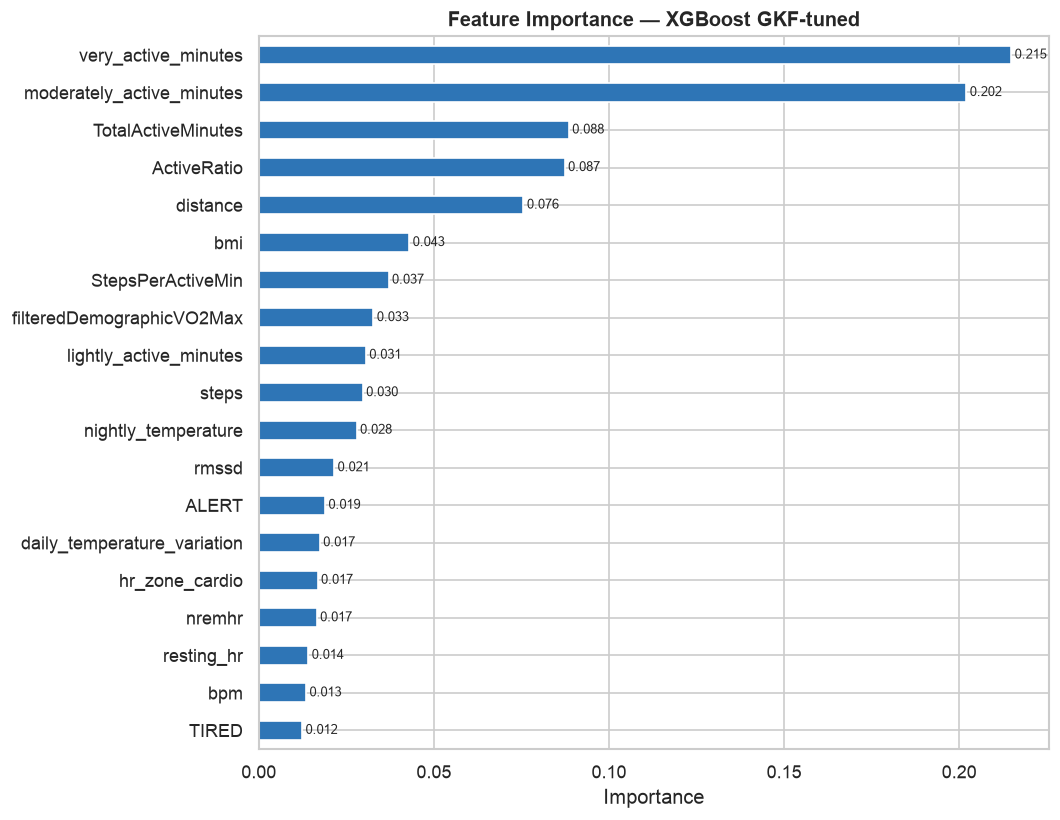

In [17]:
# Feature importance — GKF-tuned model
pipe_gkf_tuned.fit(X, y)
importances = pd.Series(
    pipe_gkf_tuned.named_steps['model'].feature_importances_,
    index=feature_cols
).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
importances.plot(kind='barh', ax=ax, color='#2E75B6')
ax.set_title('Feature Importance — XGBoost GKF-tuned', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
for i, v in enumerate(importances):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Feature Importance — Pre-Selected 19 Features

> Starting from the 19 features selected in notebook 01 (XGBoost cumulative-95% importance).
> No further selection is applied here — we simply inspect importance within this reduced set.


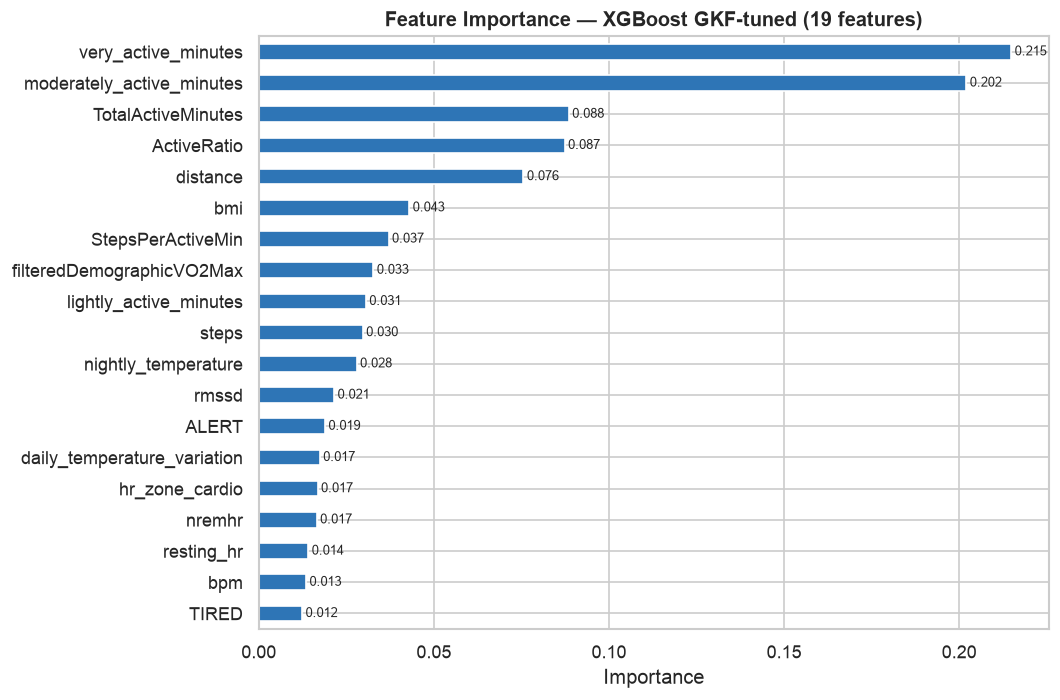

Total features: 19
Sum of importances: 1.0000


In [18]:
# Feature importance of the 19 pre-selected features (XGBoost GKF-tuned)
pipe_gkf_tuned.fit(X, y)
importances = pd.Series(
    pipe_gkf_tuned.named_steps['model'].feature_importances_,
    index=feature_cols
).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='#2E75B6')
ax.set_title(f'Feature Importance — XGBoost GKF-tuned ({len(feature_cols)} features)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
for i, v in enumerate(importances):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Total features: {len(feature_cols)}')
print(f'Sum of importances: {importances.sum():.4f}')


In [19]:
# Cumulative importance summary for the 19 features
pipe_gkf_tuned.fit(X, y)
importances = pd.Series(
    pipe_gkf_tuned.named_steps['model'].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

cumulative = importances.cumsum() / importances.sum()
summary = pd.DataFrame({
    'importance': importances,
    'cumulative_%': (cumulative * 100).round(1),
})
print('=== Feature Importance & Cumulative Coverage (19 features) ===')
print(summary.round(4).to_string())
print(f'\nTop-5 features cover {(importances.head(5).sum()/importances.sum()*100):.1f}% of total importance')


=== Feature Importance & Cumulative Coverage (19 features) ===
                             importance  cumulative_%
very_active_minutes              0.2148     21.500000
moderately_active_minutes        0.2020     41.700001
TotalActiveMinutes               0.0885     50.500000
ActiveRatio                      0.0873     59.299999
distance                         0.0756     66.800003
bmi                              0.0429     71.099998
StepsPerActiveMin                0.0370     74.800003
filteredDemographicVO2Max        0.0327     78.099998
lightly_active_minutes           0.0306     81.099998
steps                            0.0297     84.099998
nightly_temperature              0.0279     86.900002
rmssd                            0.0215     89.099998
ALERT                            0.0189     90.900002
daily_temperature_variation      0.0174     92.699997
hr_zone_cardio                   0.0168     94.400002
nremhr                           0.0165     96.000000
resting_hr         

### 9b. Feature Importance — Tree Models (RF, Gradient Boosting, LightGBM)


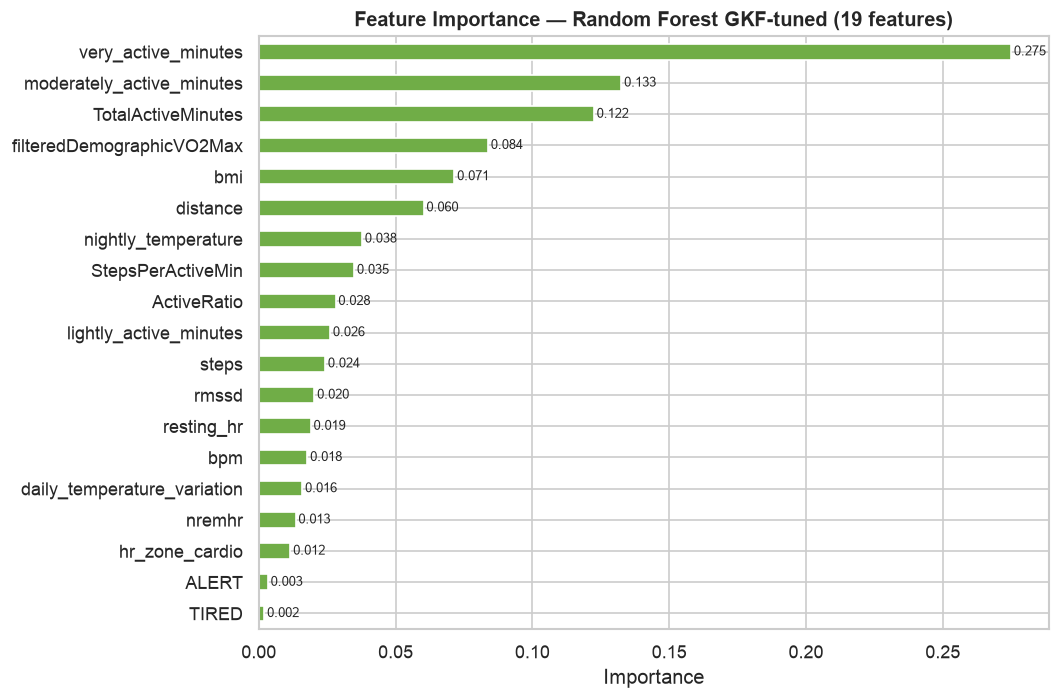

In [20]:
# Feature importance — Random Forest GKF-tuned
pipe_rf = tuned_pipes_gkf['Random Forest']
pipe_rf.fit(X, y)
importances_rf = pd.Series(
    pipe_rf.named_steps['model'].feature_importances_,
    index=feature_cols
).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
importances_rf.plot(kind='barh', ax=ax, color='#70AD47')
ax.set_title(f'Feature Importance — Random Forest GKF-tuned ({len(feature_cols)} features)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
for i, v in enumerate(importances_rf):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


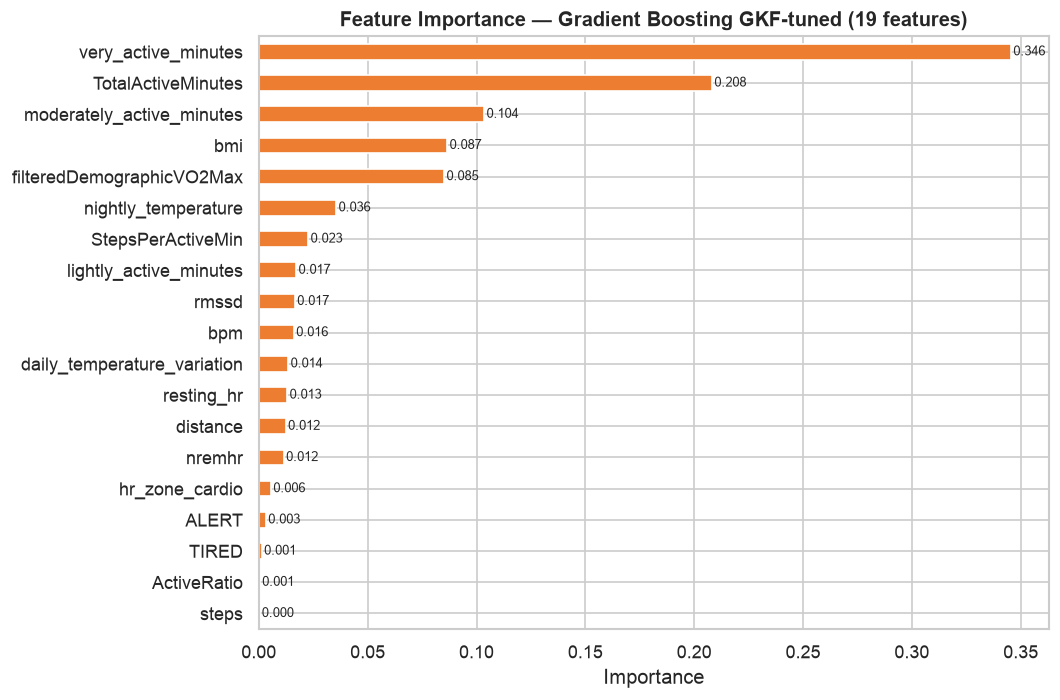

In [21]:
# Feature importance — Gradient Boosting GKF-tuned
pipe_gb = tuned_pipes_gkf['Gradient Boosting']
pipe_gb.fit(X, y)
importances_gb = pd.Series(
    pipe_gb.named_steps['model'].feature_importances_,
    index=feature_cols
).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
importances_gb.plot(kind='barh', ax=ax, color='#ED7D31')
ax.set_title(f'Feature Importance — Gradient Boosting GKF-tuned ({len(feature_cols)} features)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
for i, v in enumerate(importances_gb):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


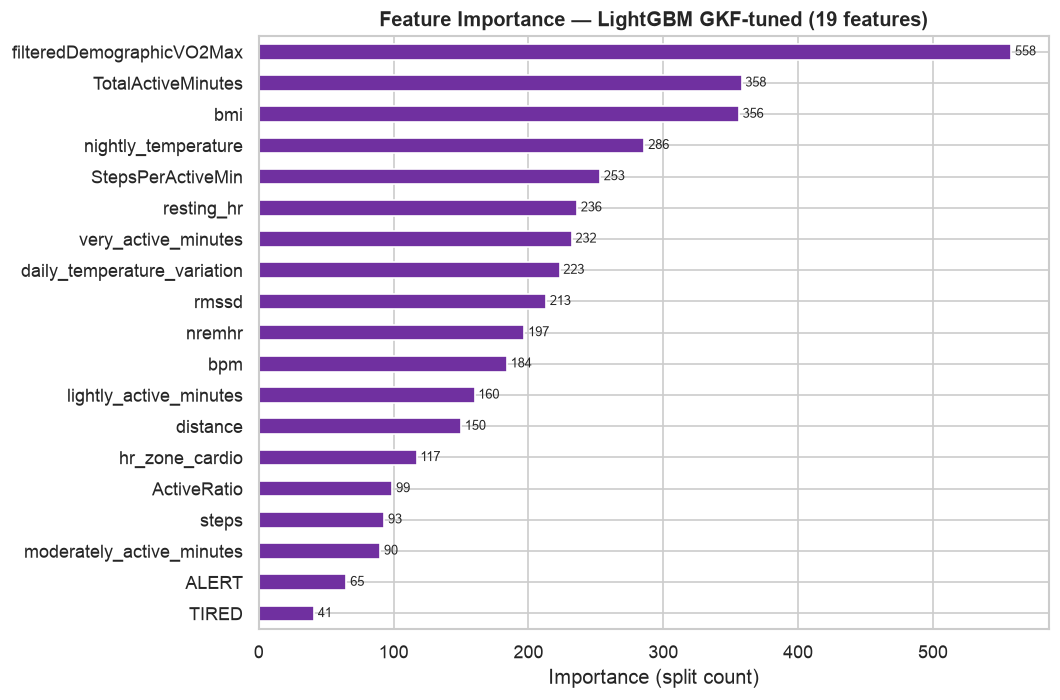

In [22]:
# Feature importance — LightGBM GKF-tuned
pipe_lgbm = tuned_pipes_gkf['LightGBM']
pipe_lgbm.fit(X, y)
importances_lgbm = pd.Series(
    pipe_lgbm.named_steps['model'].feature_importances_,
    index=feature_cols
).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
importances_lgbm.plot(kind='barh', ax=ax, color='#7030A0')
ax.set_title(f'Feature Importance — LightGBM GKF-tuned ({len(feature_cols)} features)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance (split count)')
for i, v in enumerate(importances_lgbm):
    ax.text(v + importances_lgbm.max() * 0.005, i, f'{v:.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


In [23]:
# Evaluate ALL models with the 19 pre-selected features (GroupKFold)
print(f'Evaluating all models on {len(feature_cols)} features (GKF-tuned, GroupKFold)...')
print()

fs_rows = []
print(f'{"Model":<22} {"GKF MAE":>10} {"GKF RMSE":>10} {"GKF R2":>8}')
print('-' * 55)

for name in default_models:
    pipe_fs = Pipeline([
        ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
        ('scaler',  StandardScaler()),
        ('model',   get_gkf_tuned_model(name)),
    ])
    cv = cross_validate(pipe_fs, X, y, cv=gkf, groups=groups, n_jobs=2,
                        scoring={'mae': 'neg_mean_absolute_error',
                                 'rmse': 'neg_mean_squared_error', 'r2': 'r2'})
    mae  = -cv['test_mae'].mean()
    rmse = np.sqrt(-cv['test_rmse'].mean())
    r2   =  cv['test_r2'].mean()
    fs_rows.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f'{name:<22} {mae:>10.1f} {rmse:>10.1f} {r2:>8.3f}')

fs_df = pd.DataFrame(fs_rows).set_index('Model')


Evaluating all models on 19 features (GKF-tuned, GroupKFold)...

Model                     GKF MAE   GKF RMSE   GKF R2
-------------------------------------------------------
Linear Regression           299.6      443.2    0.601
Ridge                       298.8      431.6    0.620
Lasso                       299.6      443.2    0.601
ElasticNet                  298.9      430.3    0.623
Random Forest               274.3      407.0    0.662
Gradient Boosting           276.5      413.8    0.651
XGBoost                     282.9      419.1    0.643
LightGBM                    281.4      415.7    0.649


## 10. Visual Comparison — All Models & CV Methods

                             KFold MAE  KFold R2  GKF MAE  GKF R2
Model                                                            
Linear Regression (default)      255.4       0.7    299.6     0.6
Ridge (default)                  255.6       0.7    299.5     0.6
Lasso (default)                  256.7       0.7    300.4     0.6
Random Forest (default)          110.1       0.9    294.5     0.6
Gradient Boosting (default)      157.4       0.9    282.3     0.6
XGBoost (default)                110.2       0.9    301.1     0.6
LightGBM (default)               108.1       0.9    292.6     0.6
XGBoost KFold-tuned (19f)         95.4       0.9    291.9     0.6
XGBoost GKF-tuned (19f)          152.0       0.9    282.9     0.6


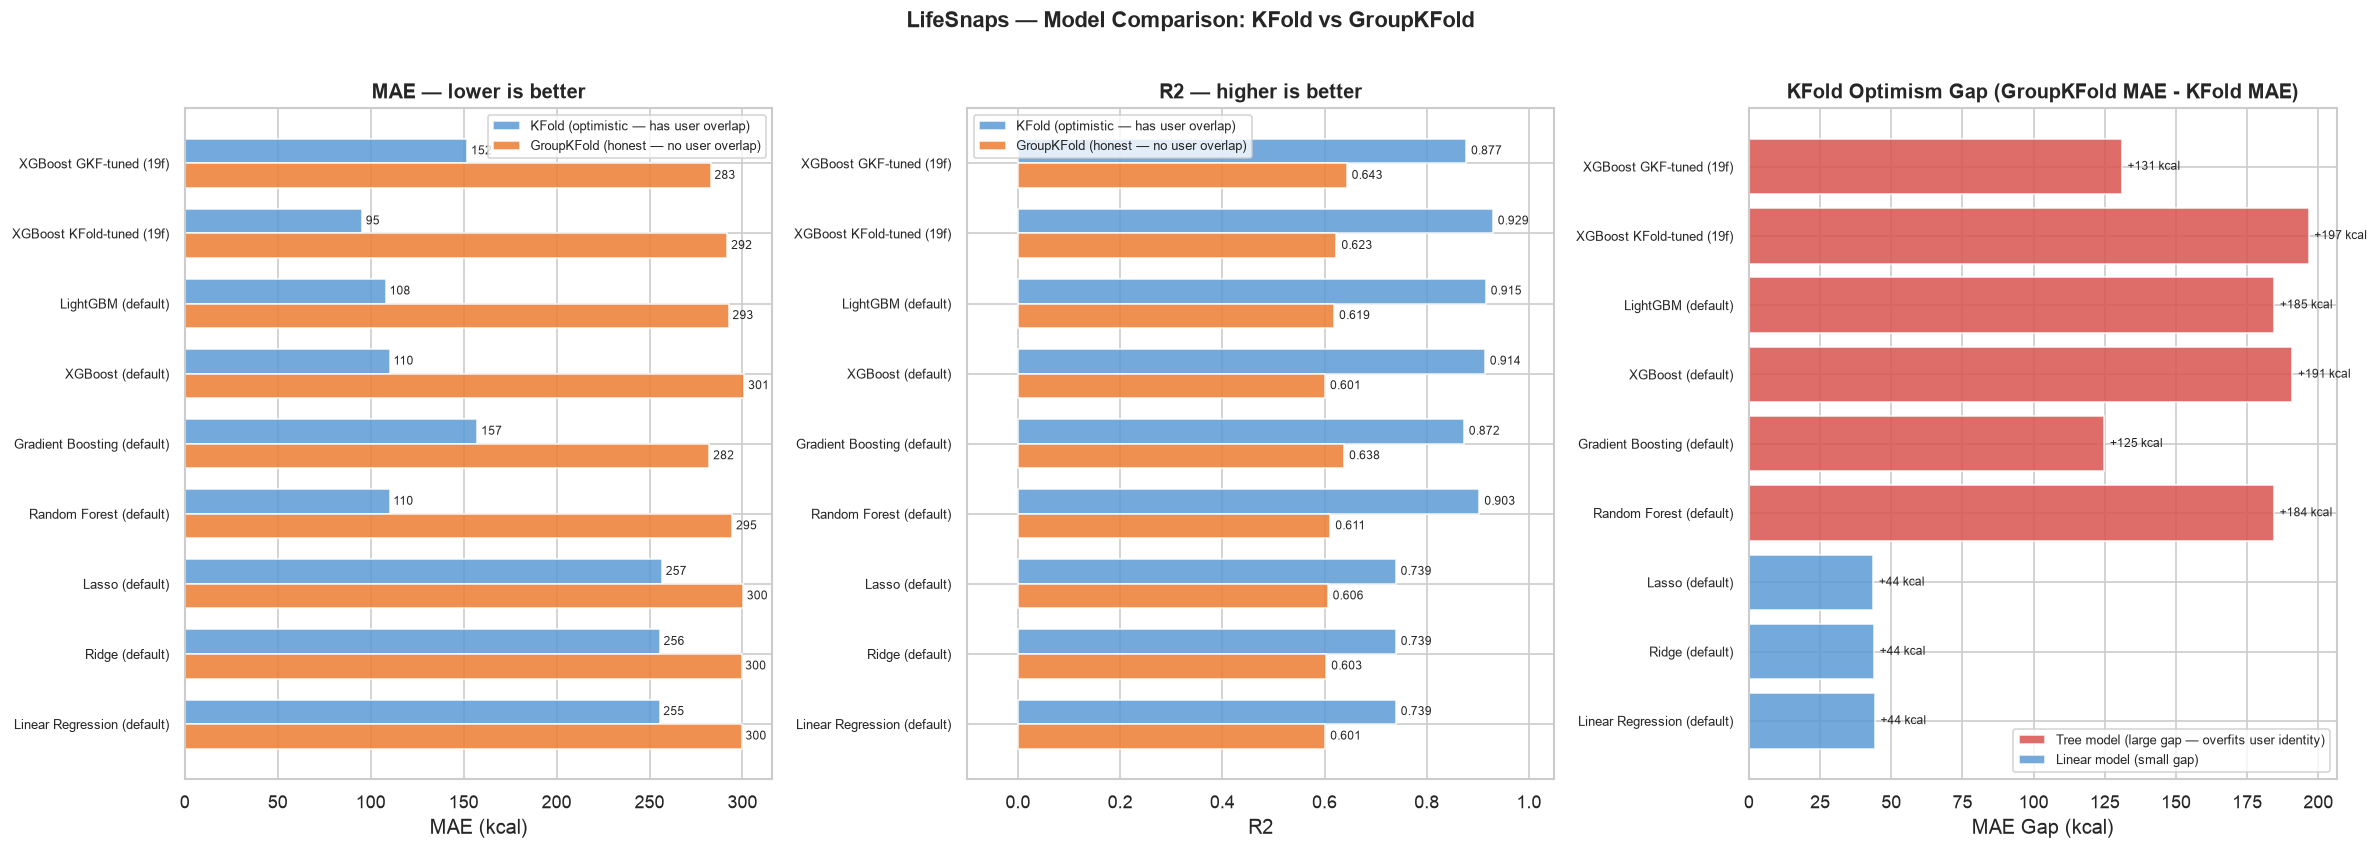

In [24]:
# Collect all results for comparison
def eval_both(pipe, X_input, label):
    scoring = {"mae": "neg_mean_absolute_error", "r2": "r2"}
    kf_res  = cross_validate(pipe, X_input, y, cv=kf,  scoring=scoring, n_jobs=2)
    gkf_res = cross_validate(pipe, X_input, y, cv=gkf, groups=groups, scoring=scoring, n_jobs=2)
    return {"Model": label,
            "KFold MAE": -kf_res["test_mae"].mean(),  "KFold R2": kf_res["test_r2"].mean(),
            "GKF MAE":  -gkf_res["test_mae"].mean(),  "GKF R2":  gkf_res["test_r2"].mean()}

rows = []
for name in ["Linear Regression", "Ridge", "Lasso", "Random Forest", "Gradient Boosting", "XGBoost", "LightGBM"]:
    pipe_b = Pipeline([
        ("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
        ("scaler",  StandardScaler()),
        ("model",   base_models[name]),
    ])
    rows.append(eval_both(pipe_b, X, name + " (default)"))

rows.append(eval_both(pipe_kfold_tuned, X, "XGBoost KFold-tuned (19f)"))
rows.append(eval_both(pipe_gkf_tuned,   X, "XGBoost GKF-tuned (19f)"))

cmp = pd.DataFrame(rows).set_index("Model")
print(cmp.round(1).to_string())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

models = cmp.index.tolist()
x = np.arange(len(models))
width = 0.35

# --- MAE ---
ax = axes[0]
b1 = ax.barh(x + width/2, cmp["KFold MAE"], width, label="KFold (optimistic — has user overlap)", color="#5B9BD5", alpha=0.85)
b2 = ax.barh(x - width/2, cmp["GKF MAE"],   width, label="GroupKFold (honest — no user overlap)", color="#ED7D31", alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(models, fontsize=8)
ax.set_xlabel("MAE (kcal)")
ax.set_title("MAE — lower is better", fontweight="bold")
ax.legend(fontsize=8)
for bar in b1: ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2, f"{bar.get_width():.0f}", va="center", fontsize=7)
for bar in b2: ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2, f"{bar.get_width():.0f}", va="center", fontsize=7)

# --- R2 ---
ax = axes[1]
b1 = ax.barh(x + width/2, cmp["KFold R2"], width, label="KFold (optimistic — has user overlap)", color="#5B9BD5", alpha=0.85)
b2 = ax.barh(x - width/2, cmp["GKF R2"],   width, label="GroupKFold (honest — no user overlap)", color="#ED7D31", alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(models, fontsize=8)
ax.set_xlabel("R2")
ax.set_title("R2 — higher is better", fontweight="bold")
ax.set_xlim(-0.1, 1.05)
ax.legend(fontsize=8)
for bar in b1: ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f"{bar.get_width():.3f}", va="center", fontsize=7)
for bar in b2: ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f"{bar.get_width():.3f}", va="center", fontsize=7)

# --- Optimism Gap ---
ax = axes[2]
gap = cmp["GKF MAE"] - cmp["KFold MAE"]
# 2 colors only: tree models (large gap) vs linear models (small gap)
is_tree = ["Linear" not in m and "Ridge" not in m and "Lasso" not in m for m in models]
colors_gap = ["#D9534F" if t else "#5B9BD5" for t in is_tree]
bars = ax.barh(x, gap, color=colors_gap, alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(models, fontsize=8)
ax.set_xlabel("MAE Gap (kcal)")
ax.set_title("KFold Optimism Gap (GroupKFold MAE - KFold MAE)", fontweight="bold")
ax.axvline(0, color="black", linewidth=0.5)
for bar, v in zip(bars, gap):
    ax.text(v+2, bar.get_y()+bar.get_height()/2, f"+{v:.0f} kcal", va="center", fontsize=7)

# Legend for gap chart
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#D9534F", alpha=0.85, label="Tree model (large gap — overfits user identity)"),
    Patch(facecolor="#5B9BD5", alpha=0.85, label="Linear model (small gap)"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="lower right")

plt.suptitle("LifeSnaps — Model Comparison: KFold vs GroupKFold", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 11. Tune ALL Models with Optuna (GroupKFold)

> Tune every model using the same honest GroupKFold CV so we can fairly compare before vs after tuning.

In [25]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

gkf = GroupKFold(n_splits=3)
N_TRIALS = 20

def run_study(objective_fn, name):
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective_fn, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)
    print(f"{name:<25} best MAE={-study.best_value:.1f}")
    return study

def gkf_score(pipe, X_input=X, scoring="neg_mean_absolute_error"):
    return cross_val_score(pipe, X_input, y, cv=gkf, groups=groups,
                           scoring=scoring, n_jobs=2).mean()

# ── Ridge ──────────────────────────────────────────────────────────────────
def obj_ridge(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 1e3, log=True)
    pipe = Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   Ridge(alpha=alpha))])
    return gkf_score(pipe)

# ── Lasso ──────────────────────────────────────────────────────────────────
def obj_lasso(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 1e2, log=True)
    pipe = Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   Lasso(alpha=alpha, max_iter=5000))])
    return gkf_score(pipe)

# ── Random Forest ──────────────────────────────────────────────────────────
def obj_rf(trial):
    params = dict(
        n_estimators    = trial.suggest_int("n_estimators", 50, 400),
        max_depth       = trial.suggest_int("max_depth", 3, 20),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10),
        max_features    = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8]),
    )
    pipe = Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   RandomForestRegressor(**params, random_state=42, n_jobs=-1))])
    return gkf_score(pipe)

# ── Gradient Boosting ──────────────────────────────────────────────────────
def obj_gb(trial):
    params = dict(
        n_estimators  = trial.suggest_int("n_estimators", 50, 500),
        max_depth     = trial.suggest_int("max_depth", 2, 6),
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample     = trial.suggest_float("subsample", 0.5, 1.0),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
    )
    pipe = Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   GradientBoostingRegressor(**params, random_state=42))])
    return gkf_score(pipe)

# ── XGBoost ────────────────────────────────────────────────────────────────
def obj_xgb(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 50, 500),
        max_depth        = trial.suggest_int("max_depth", 2, 8),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample        = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
        reg_alpha        = trial.suggest_float("reg_alpha", 0.0, 5.0),
        reg_lambda       = trial.suggest_float("reg_lambda", 1.0, 10.0),
    )
    pipe = Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   XGBRegressor(**params, random_state=42, verbosity=0, n_jobs=2))])
    return gkf_score(pipe)

# ── LightGBM ───────────────────────────────────────────────────────────────
def obj_lgbm(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 50, 500),
        max_depth        = trial.suggest_int("max_depth", 2, 8),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample        = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_samples = trial.suggest_int("min_child_samples", 5, 50),
        reg_alpha        = trial.suggest_float("reg_alpha", 0.0, 5.0),
        reg_lambda       = trial.suggest_float("reg_lambda", 1.0, 10.0),
    )
    pipe = Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   lgb.LGBMRegressor(**params, random_state=42, verbose=-1, n_jobs=2))])
    return gkf_score(pipe)

print(f"Tuning all models ({N_TRIALS} Optuna trials each, GroupKFold)...")
study_ridge = run_study(obj_ridge, "Ridge")
study_lasso = run_study(obj_lasso, "Lasso")
study_rf    = run_study(obj_rf,    "Random Forest")
study_gb    = run_study(obj_gb,    "Gradient Boosting")
study_xgb   = run_study(obj_xgb,  "XGBoost")
study_lgbm  = run_study(obj_lgbm, "LightGBM")
print("Done!")

Tuning all models (20 Optuna trials each, GroupKFold)...
Ridge                     best MAE=298.8
Lasso                     best MAE=299.6
Random Forest             best MAE=274.3
Gradient Boosting         best MAE=276.5
XGBoost                   best MAE=282.9
LightGBM                  best MAE=281.4
Done!


## 12. Before vs After Tuning — Full Comparison

In [26]:
def eval_gkf(pipe, X_input=X):
    cv  = cross_validate(pipe, X_input, y, cv=gkf, groups=groups, n_jobs=2, scoring={
        "mae": "neg_mean_absolute_error", "rmse": "neg_mean_squared_error", "r2": "r2"})
    return -cv["test_mae"].mean(), np.sqrt(-cv["test_rmse"].mean()), cv["test_r2"].mean()

def make_pipe(model):
    return Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   model)])

# ── Default (before tuning) ────────────────────────────────────────────────
defaults = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "Lasso":             Lasso(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=2),
    "LightGBM":          lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=2),
}

# ── Tuned (after tuning) ───────────────────────────────────────────────────
tuned = {
    "Linear Regression": LinearRegression(),   # no hyperparams
    "Ridge":             Ridge(**study_ridge.best_params),
    "Lasso":             Lasso(**{k: v for k, v in study_lasso.best_params.items()}, max_iter=5000),
    "Random Forest":     RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(**study_gb.best_params, random_state=42),
    "XGBoost":           XGBRegressor(**study_xgb.best_params, random_state=42, verbosity=0, n_jobs=2),
    "LightGBM":          lgb.LGBMRegressor(**study_lgbm.best_params, random_state=42, verbose=-1, n_jobs=2),
}

rows = []
for name in defaults:
    mae_b, rmse_b, r2_b = eval_gkf(make_pipe(defaults[name]))
    mae_t, rmse_t, r2_t = eval_gkf(make_pipe(tuned[name]))
    rows.append({"Model": name,
                 "MAE_before": mae_b,  "MAE_after": mae_t,
                 "RMSE_before": rmse_b, "RMSE_after": rmse_t,
                 "R2_before": r2_b,   "R2_after": r2_t})
    print(f"{name:<22} MAE {mae_b:.1f}→{mae_t:.1f}  RMSE {rmse_b:.1f}→{rmse_t:.1f}  R² {r2_b:.3f}→{r2_t:.3f}")

cmp_all = pd.DataFrame(rows).set_index("Model")


Linear Regression      MAE 299.6→299.6  RMSE 443.2→443.2  R² 0.601→0.601
Ridge                  MAE 299.5→298.8  RMSE 442.1→431.6  R² 0.603→0.620
Lasso                  MAE 300.4→299.6  RMSE 440.3→443.2  R² 0.606→0.601
Random Forest          MAE 294.5→274.3  RMSE 433.7→407.0  R² 0.611→0.662
Gradient Boosting      MAE 282.3→276.5  RMSE 421.0→413.8  R² 0.638→0.651
XGBoost                MAE 301.1→282.9  RMSE 441.4→419.1  R² 0.601→0.643
LightGBM               MAE 292.6→281.4  RMSE 431.0→415.7  R² 0.619→0.649


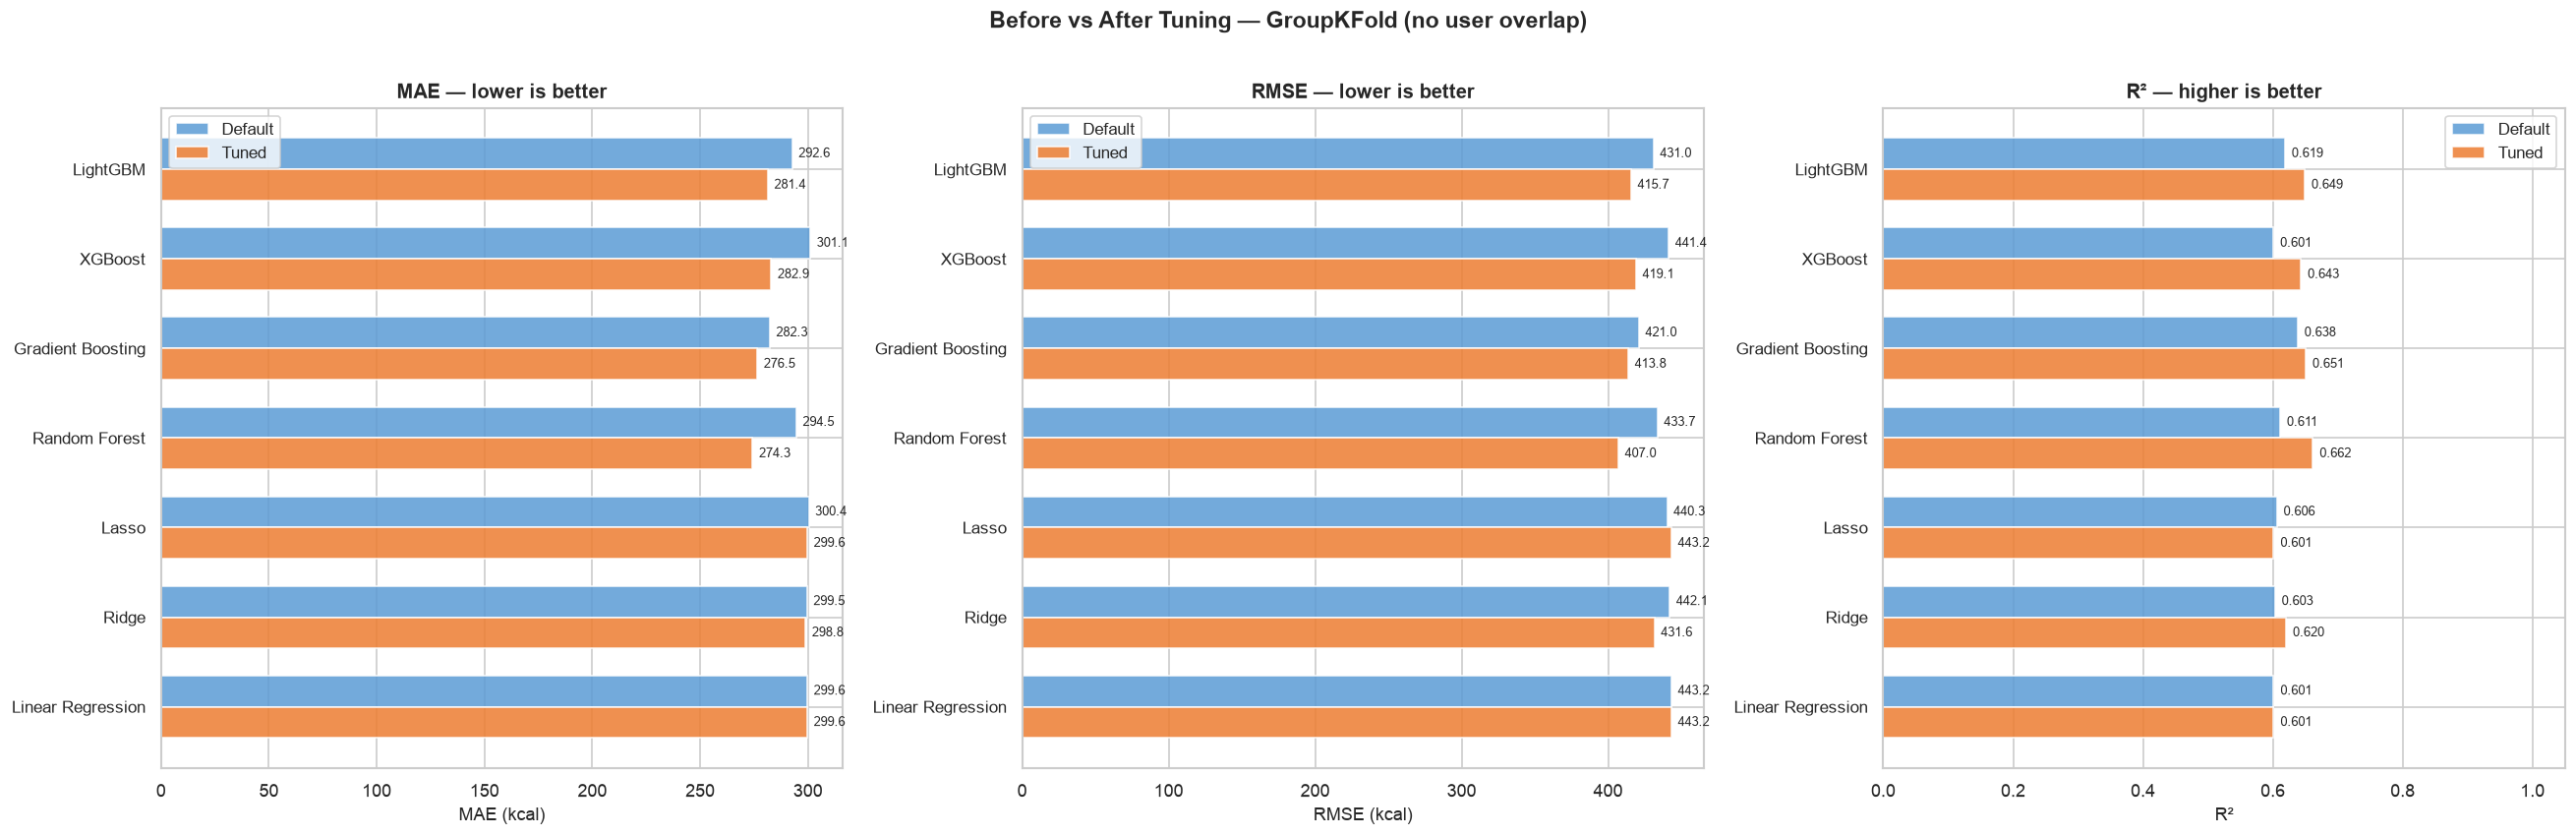

=== Improvement from Tuning (GroupKFold MAE) ===
                   MAE_before  MAE_after  MAE_improvement  MAE_improvement_%
Model                                                                       
Linear Regression       299.6      299.6              0.0                0.0
Ridge                   299.5      298.8              0.7                0.2
Lasso                   300.4      299.6              0.7                0.2
Random Forest           294.5      274.3             20.2                6.9
Gradient Boosting       282.3      276.5              5.8                2.0
XGBoost                 301.1      282.9             18.1                6.0
LightGBM                292.6      281.4             11.3                3.9


In [27]:
# ── Plot: Before vs After for MAE, RMSE, R² ──────────────────────────────
model_names = cmp_all.index.tolist()
x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Before vs After Tuning — GroupKFold (no user overlap)",
             fontsize=14, fontweight="bold", y=1.01)

metric_cfg = [
    ("MAE",  "MAE_before",  "MAE_after",  "MAE (kcal)",  True,  (0, None)),
    ("RMSE", "RMSE_before", "RMSE_after", "RMSE (kcal)", True,  (0, None)),
    ("R²",   "R2_before",   "R2_after",   "R²",          False, (0, 1.05)),
]

for ax, (title, col_b, col_a, xlabel, lower_better, ylim) in zip(axes, metric_cfg):
    bars_b = ax.barh(x + width/2, cmp_all[col_b], width,
                     label="Default", color="#5B9BD5", alpha=0.85)
    bars_a = ax.barh(x - width/2, cmp_all[col_a], width,
                     label="Tuned",   color="#ED7D31", alpha=0.85)
    ax.set_yticks(x)
    ax.set_yticklabels(model_names, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=11)
    direction = "lower is better" if lower_better else "higher is better"
    ax.set_title(f"{title} — {direction}", fontweight="bold", fontsize=12)
    ax.set_xlim(ylim)
    ax.legend(fontsize=10)
    # Value labels
    for bar in bars_b:
        v = bar.get_width()
        ax.text(v + (ylim[1] or cmp_all[col_b].max()) * 0.01,
                bar.get_y() + bar.get_height()/2,
                f"{v:.1f}" if title != "R²" else f"{v:.3f}",
                va="center", fontsize=8)
    for bar in bars_a:
        v = bar.get_width()
        ax.text(v + (ylim[1] or cmp_all[col_b].max()) * 0.01,
                bar.get_y() + bar.get_height()/2,
                f"{v:.1f}" if title != "R²" else f"{v:.3f}",
                va="center", fontsize=8)

plt.tight_layout()
plt.show()

# ── Improvement summary ───────────────────────────────────────────────────
print("=== Improvement from Tuning (GroupKFold MAE) ===")
cmp_all["MAE_improvement"] = cmp_all["MAE_before"] - cmp_all["MAE_after"]
cmp_all["MAE_improvement_%"] = (cmp_all["MAE_improvement"] / cmp_all["MAE_before"] * 100).round(1)
print(cmp_all[["MAE_before","MAE_after","MAE_improvement","MAE_improvement_%"]].round(1).to_string())


=== Final Tuned Models — Ranked by MAE (GroupKFold) ===
                       MAE     RMSE     R2
Model                                     
Random Forest      274.299  406.989  0.662
Gradient Boosting  276.498  413.781  0.651
LightGBM           281.358  415.702  0.649
XGBoost            282.932  419.070  0.643
Ridge              298.847  431.630  0.620
Linear Regression  299.636  443.219  0.601
Lasso              299.637  443.216  0.601


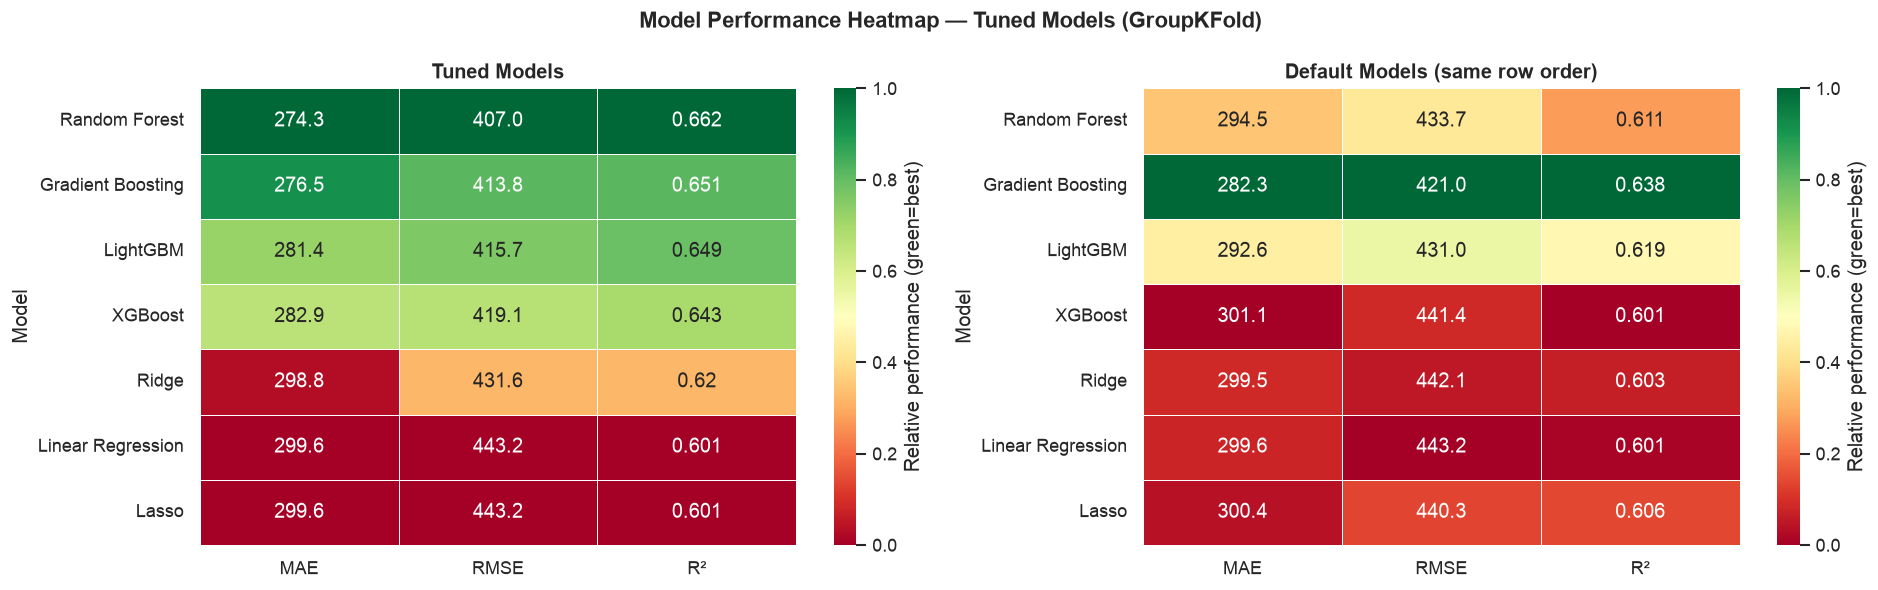

In [28]:
# ── Ranked final tuned model comparison (all metrics) ────────────────────
print("=== Final Tuned Models — Ranked by MAE (GroupKFold) ===")
ranked = cmp_all[["MAE_after", "RMSE_after", "R2_after"]].copy()
ranked.columns = ["MAE", "RMSE", "R2"]
ranked = ranked.sort_values("MAE")
print(ranked.round(3).to_string())

# ── Heatmap of all metrics ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Model Performance Heatmap — Tuned Models (GroupKFold)",
             fontsize=13, fontweight="bold")

# Normalize each metric for coloring (0=worst, 1=best)
def normalize_col(s, lower_better=True):
    mn, mx = s.min(), s.max()
    if mx == mn: return pd.Series([0.5]*len(s), index=s.index)
    normed = (s - mn) / (mx - mn)
    return 1 - normed if lower_better else normed

heatmap_data = pd.DataFrame({
    "MAE":  normalize_col(ranked["MAE"],  lower_better=True),
    "RMSE": normalize_col(ranked["RMSE"], lower_better=True),
    "R²":   normalize_col(ranked["R2"],   lower_better=False),
})
annot_data = pd.DataFrame({
    "MAE":  ranked["MAE"].round(1).astype(str),
    "RMSE": ranked["RMSE"].round(1).astype(str),
    "R²":   ranked["R2"].round(3).astype(str),
})

sns.heatmap(heatmap_data, annot=annot_data, fmt="", cmap="RdYlGn",
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5,
            cbar_kws={"label": "Relative performance (green=best)"})
axes[0].set_title("Tuned Models", fontweight="bold")
axes[0].set_xlabel("")

# Before tuning heatmap
before_data_raw = cmp_all[["MAE_before","RMSE_before","R2_before"]].copy()
before_data_raw.columns = ["MAE","RMSE","R2"]
before_data_raw = before_data_raw.loc[ranked.index]   # same row order
heatmap_before = pd.DataFrame({
    "MAE":  normalize_col(before_data_raw["MAE"],  lower_better=True),
    "RMSE": normalize_col(before_data_raw["RMSE"], lower_better=True),
    "R²":   normalize_col(before_data_raw["R2"],   lower_better=False),
})
annot_before = pd.DataFrame({
    "MAE":  before_data_raw["MAE"].round(1).astype(str),
    "RMSE": before_data_raw["RMSE"].round(1).astype(str),
    "R²":   before_data_raw["R2"].round(3).astype(str),
})
sns.heatmap(heatmap_before, annot=annot_before, fmt="", cmap="RdYlGn",
            vmin=0, vmax=1, ax=axes[1], linewidths=0.5,
            cbar_kws={"label": "Relative performance (green=best)"})
axes[1].set_title("Default Models (same row order)", fontweight="bold")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


## 13. TimeSeriesSplit — Predict Future of Known User

> 🟢 **Evaluation: TimeSeriesSplit (3 splits, sorted by date)**  
> Train on past → test on future. No temporal leakage. User overlap allowed.  
> Goal: *given this user's history → predict their future calories*

| CV Method | Temporal leakage | User overlap | เหมาะกับ |
|---|---|---|---|
| KFold | ⚠️ Yes | ⚠️ Yes | baseline เปรียบเทียบ |
| GroupKFold | ⚠️ Yes | ✅ No | predict user ใหม่ |
| **TimeSeriesSplit** | ✅ No | ⚠️ Yes | predict อนาคต user เดิม |

In [29]:
from sklearn.model_selection import TimeSeriesSplit

# Sort by date — required for TimeSeriesSplit
df_sorted     = df.sort_values(['date']).reset_index(drop=True)
X_sorted      = df_sorted[['id'] + feature_cols]
y_sorted      = df_sorted[target]
groups_sorted = df_sorted['id']

tscv = TimeSeriesSplit(n_splits=3)

print(f'Data sorted by date: {df_sorted["date"].min().date()} → {df_sorted["date"].max().date()}')
print(f'Rows: {len(df_sorted)} | Users: {df_sorted["id"].nunique()}')

# Show fold sizes
for fold, (tr, te) in enumerate(tscv.split(X_sorted), 1):
    print(f'  Fold {fold}: train={len(tr):,}  test={len(te):,}  '
          f'test dates: {df_sorted["date"].iloc[te[0]].date()} → {df_sorted["date"].iloc[te[-1]].date()}')

Data sorted by date: 2021-05-24 → 2022-01-21
Rows: 6638 | Users: 71
  Fold 1: train=1,661  test=1,659  test dates: 2021-07-04 → 2021-09-01
  Fold 2: train=3,320  test=1,659  test dates: 2021-09-01 → 2021-12-02
  Fold 3: train=4,979  test=1,659  test dates: 2021-12-02 → 2022-01-21


In [30]:
def tscv_eval(pipe, X_input=X_sorted, label=''):
    cv = cross_validate(pipe, X_input, y_sorted, cv=tscv, n_jobs=2, scoring={
        'mae': 'neg_mean_absolute_error', 'rmse': 'neg_mean_squared_error', 'r2': 'r2'})
    mae  = -cv['test_mae'].mean()
    rmse = np.sqrt(-cv['test_rmse'].mean())
    r2   = cv['test_r2'].mean()
    if label:
        print(f'{label:<40} MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}')
    return mae, rmse, r2

print('TimeSeriesSplit evaluation — Default models:')
print('-' * 70)
tscv_default = {}
for name, model in default_models.items():
    pipe = make_pipe(model)
    tscv_default[name] = tscv_eval(pipe, label=f'{name} (default)')

print('\nTimeSeriesSplit evaluation — GKF-tuned models:')
print('-' * 70)
tscv_gkf_tuned = {}
for name in default_models:
    pipe = make_pipe(get_gkf_tuned_model(name))
    tscv_gkf_tuned[name] = tscv_eval(pipe, label=f'{name} (GKF-tuned)')

TimeSeriesSplit evaluation — Default models:
----------------------------------------------------------------------
Linear Regression (default)              MAE=286.3  RMSE=369.5  R²=0.691
Ridge (default)                          MAE=286.5  RMSE=369.7  R²=0.691
Lasso (default)                          MAE=287.1  RMSE=370.0  R²=0.691
ElasticNet (default)                     MAE=308.0  RMSE=383.9  R²=0.667
Random Forest (default)                  MAE=178.5  RMSE=309.1  R²=0.786
Gradient Boosting (default)              MAE=197.7  RMSE=312.5  R²=0.781
XGBoost (default)                        MAE=170.6  RMSE=300.5  R²=0.797
LightGBM (default)                       MAE=170.3  RMSE=300.6  R²=0.797

TimeSeriesSplit evaluation — GKF-tuned models:
----------------------------------------------------------------------
Linear Regression (GKF-tuned)            MAE=286.3  RMSE=369.5  R²=0.691
Ridge (GKF-tuned)                        MAE=289.4  RMSE=371.9  R²=0.687
Lasso (GKF-tuned)                  

In [31]:
def make_obj_tscv(model_fn):
    def objective(trial):
        pipe = Pipeline([
            ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
            ('scaler',  StandardScaler()),
            ('model',   model_fn(trial)),
        ])
        return cross_val_score(pipe, X_sorted, y_sorted, cv=tscv,
                               scoring='neg_mean_absolute_error', n_jobs=2).mean()
    return objective

studies_tscv = {}
print(f'Retuning all models ({N_TRIALS} trials each, TimeSeriesSplit)...')
for name, fn in model_fns.items():
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_obj_tscv(fn), n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)
    studies_tscv[name] = study
    print(f'  {name:<22} GKF-tuned MAE={tscv_gkf_tuned[name][0]:.1f}  '
          f'TSCV-tuned MAE={-study.best_value:.1f}  '
          f'Δ={tscv_gkf_tuned[name][0] - (-study.best_value):+.1f}')
studies_tscv['Linear Regression'] = None
print('Done!')

Retuning all models (20 trials each, TimeSeriesSplit)...
  Ridge                  GKF-tuned MAE=289.4  TSCV-tuned MAE=286.3  Δ=+3.1
  Lasso                  GKF-tuned MAE=286.3  TSCV-tuned MAE=286.3  Δ=+0.0
  ElasticNet             GKF-tuned MAE=288.9  TSCV-tuned MAE=286.3  Δ=+2.6
  Random Forest          GKF-tuned MAE=191.7  TSCV-tuned MAE=181.9  Δ=+9.8
  Gradient Boosting      GKF-tuned MAE=208.4  TSCV-tuned MAE=162.9  Δ=+45.5
  XGBoost                GKF-tuned MAE=199.8  TSCV-tuned MAE=163.6  Δ=+36.2
  LightGBM               GKF-tuned MAE=200.3  TSCV-tuned MAE=166.2  Δ=+34.0
Done!


=== 3-Way CV Comparison (tuned models) ===
                   KFold MAE  GKF MAE (tuned)  TSCV MAE (tuned)
Model                                                          
Linear Regression      255.4            299.6             286.3
Ridge                  255.6            298.8             286.3
Lasso                  256.7            299.6             286.3
ElasticNet             289.5            298.9             286.3
Random Forest          110.1            274.3             181.9
Gradient Boosting      157.4            276.5             162.9
XGBoost                110.2            282.9             163.6
LightGBM               108.1            281.4             166.2

KFold  → leaky, optimistic
GKF    → honest for NEW user
TSCV   → honest for SAME user future prediction


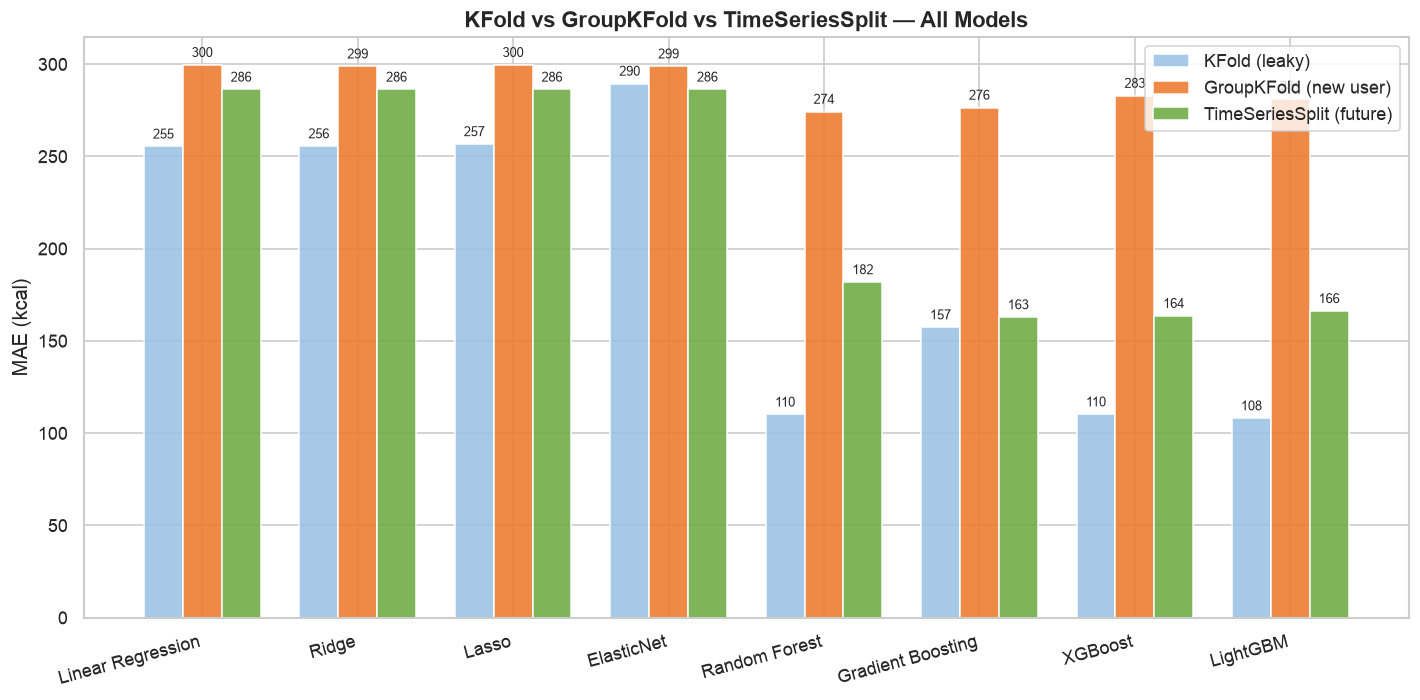

In [32]:
def get_tscv_tuned_model(name):
    study = studies_tscv[name]
    if name == 'Linear Regression' or study is None:
        return LinearRegression()
    p = study.best_params
    if name == 'Ridge':             return Ridge(alpha=p['alpha'])
    if name == 'Lasso':             return Lasso(alpha=p['alpha'], max_iter=5000)
    if name == 'ElasticNet':        return ElasticNet(alpha=p['alpha'], l1_ratio=p['l1_ratio'], max_iter=5000)
    if name == 'Random Forest':     return RandomForestRegressor(**p, random_state=42, n_jobs=-1)
    if name == 'Gradient Boosting': return GradientBoostingRegressor(**p, random_state=42)
    if name == 'XGBoost':           return XGBRegressor(**p, random_state=42, verbosity=0, n_jobs=2)
    if name == 'LightGBM':          return lgb.LGBMRegressor(**p, random_state=42, verbose=-1, n_jobs=2)

rows = []
for name in default_models:
    tscv_mae = -cross_val_score(
        make_pipe(get_tscv_tuned_model(name)), X_sorted, y_sorted,
        cv=tscv, scoring='neg_mean_absolute_error', n_jobs=2).mean()
    rows.append({
        'Model':            name,
        'KFold MAE':        results[name]['MAE'],
        'GKF MAE (tuned)':  summary_df.loc[name, 'GKF MAE (GKF-tuned)'],
        'TSCV MAE (tuned)': tscv_mae,
    })

cmp_tscv = pd.DataFrame(rows).set_index('Model')
print('=== 3-Way CV Comparison (tuned models) ===')
print(cmp_tscv.round(1).to_string())
print()
print('KFold  → leaky, optimistic')
print('GKF    → honest for NEW user')
print('TSCV   → honest for SAME user future prediction')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(cmp_tscv))
width = 0.25

b1 = ax.bar(x - width, cmp_tscv['KFold MAE'],        width, label='KFold (leaky)',          color='#9DC3E6', alpha=0.9)
b2 = ax.bar(x,          cmp_tscv['GKF MAE (tuned)'],  width, label='GroupKFold (new user)',   color='#ED7D31', alpha=0.9)
b3 = ax.bar(x + width,  cmp_tscv['TSCV MAE (tuned)'], width, label='TimeSeriesSplit (future)',color='#70AD47', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(cmp_tscv.index, rotation=15, ha='right')
ax.set_ylabel('MAE (kcal)')
ax.set_title('KFold vs GroupKFold vs TimeSeriesSplit — All Models', fontweight='bold', fontsize=13)
ax.legend()
ax.bar_label(b1, fmt='%.0f', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.0f', padding=3, fontsize=8)
ax.bar_label(b3, fmt='%.0f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

## 14. Within-User Prediction

> 🟣 **Evaluation: Per-user TimeSeriesSplit**  
> For each user: train on their early days → test on their later days.  
> Model trained on ALL users' train data, tested only on each user's held-out future.  
> Goal: *how well can we predict a known user's future calories?*

| CV Method | Temporal leakage | User overlap | เหมาะกับ |
|---|---|---|---|
| KFold | ⚠️ Yes | ⚠️ Yes | baseline |
| GroupKFold | ⚠️ Yes | ✅ No | predict user ใหม่ |
| TimeSeriesSplit | ✅ No | ⚠️ Yes | predict อนาคต (mixed users) |
| **Within-User** | ✅ No | ✅ No | predict อนาคต user เดิม (strictest) |

In [33]:
# ── Within-user split: for each user, last 20% of days = test ────────────
df_sorted2 = df.sort_values(['id', 'date']).reset_index(drop=True)

train_idx_wu, test_idx_wu = [], []
for uid, grp in df_sorted2.groupby('id'):
    n      = len(grp)
    n_test = max(1, int(n * 0.2))
    train_idx_wu.extend(grp.index[:-n_test].tolist())
    test_idx_wu.extend(grp.index[-n_test:].tolist())

X_wu = df_sorted2[['id'] + feature_cols]
y_wu = df_sorted2[target]

print(f'Within-user split:')
print(f'  Train: {len(train_idx_wu):,} rows ({len(train_idx_wu)/len(df_sorted2)*100:.0f}%)')
print(f'  Test:  {len(test_idx_wu):,} rows  ({len(test_idx_wu)/len(df_sorted2)*100:.0f}%)')
print(f'  Every user has future test days held out')

X_train_wu = X_wu.iloc[train_idx_wu]
X_test_wu  = X_wu.iloc[test_idx_wu]
y_train_wu = y_wu.iloc[train_idx_wu]
y_test_wu  = y_wu.iloc[test_idx_wu]

Within-user split:
  Train: 5,342 rows (80%)
  Test:  1,296 rows  (20%)
  Every user has future test days held out


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def wu_eval(model_obj, label):
    pipe = make_pipe(model_obj)
    pipe.fit(X_train_wu, y_train_wu)
    y_pred = pipe.predict(X_test_wu)
    mae  = mean_absolute_error(y_test_wu, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_wu, y_pred))
    r2   = r2_score(y_test_wu, y_pred)
    print(f'{label:<40} MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}')
    return mae, rmse, r2

print('Within-User evaluation — Default models:')
print('-' * 70)
wu_default = {}
for name, model in default_models.items():
    wu_default[name] = wu_eval(model, f'{name} (default)')

print('\nWithin-User evaluation — GKF-tuned models:')
print('-' * 70)
wu_gkf_tuned = {}
for name in default_models:
    wu_gkf_tuned[name] = wu_eval(get_gkf_tuned_model(name), f'{name} (GKF-tuned)')

Within-User evaluation — Default models:
----------------------------------------------------------------------
Linear Regression (default)              MAE=261.0  RMSE=329.3  R²=0.752
Ridge (default)                          MAE=261.2  RMSE=329.5  R²=0.752
Lasso (default)                          MAE=263.5  RMSE=331.8  R²=0.748
ElasticNet (default)                     MAE=301.7  RMSE=372.3  R²=0.683
Random Forest (default)                  MAE=112.2  RMSE=226.3  R²=0.883
Gradient Boosting (default)              MAE=163.0  RMSE=250.9  R²=0.856
XGBoost (default)                        MAE=115.5  RMSE=239.0  R²=0.869
LightGBM (default)                       MAE=119.7  RMSE=226.7  R²=0.883

Within-User evaluation — GKF-tuned models:
----------------------------------------------------------------------
Linear Regression (GKF-tuned)            MAE=261.0  RMSE=329.3  R²=0.752
Ridge (GKF-tuned)                        MAE=264.2  RMSE=332.6  R²=0.747
Lasso (GKF-tuned)                        MA

=== 4-Way CV Comparison ===
                   KFold MAE  GKF MAE (tuned)  TSCV MAE (tuned)  Within-User MAE
Model                                                                           
Linear Regression      255.4            299.6             286.3            261.0
Ridge                  255.6            298.8             289.4            264.2
Lasso                  256.7            299.6             286.3            261.1
ElasticNet             289.5            298.9             288.9            265.5
Random Forest          110.1            274.3             191.7            122.2
Gradient Boosting      157.4            276.5             208.4            180.9
XGBoost                110.2            282.9             199.8            157.6
LightGBM               108.1            281.4             200.3            159.7

KFold       → leaky, optimistic
GKF         → honest for NEW user
TSCV        → honest, mixed users, future dates
Within-User → strictest: same user, future date

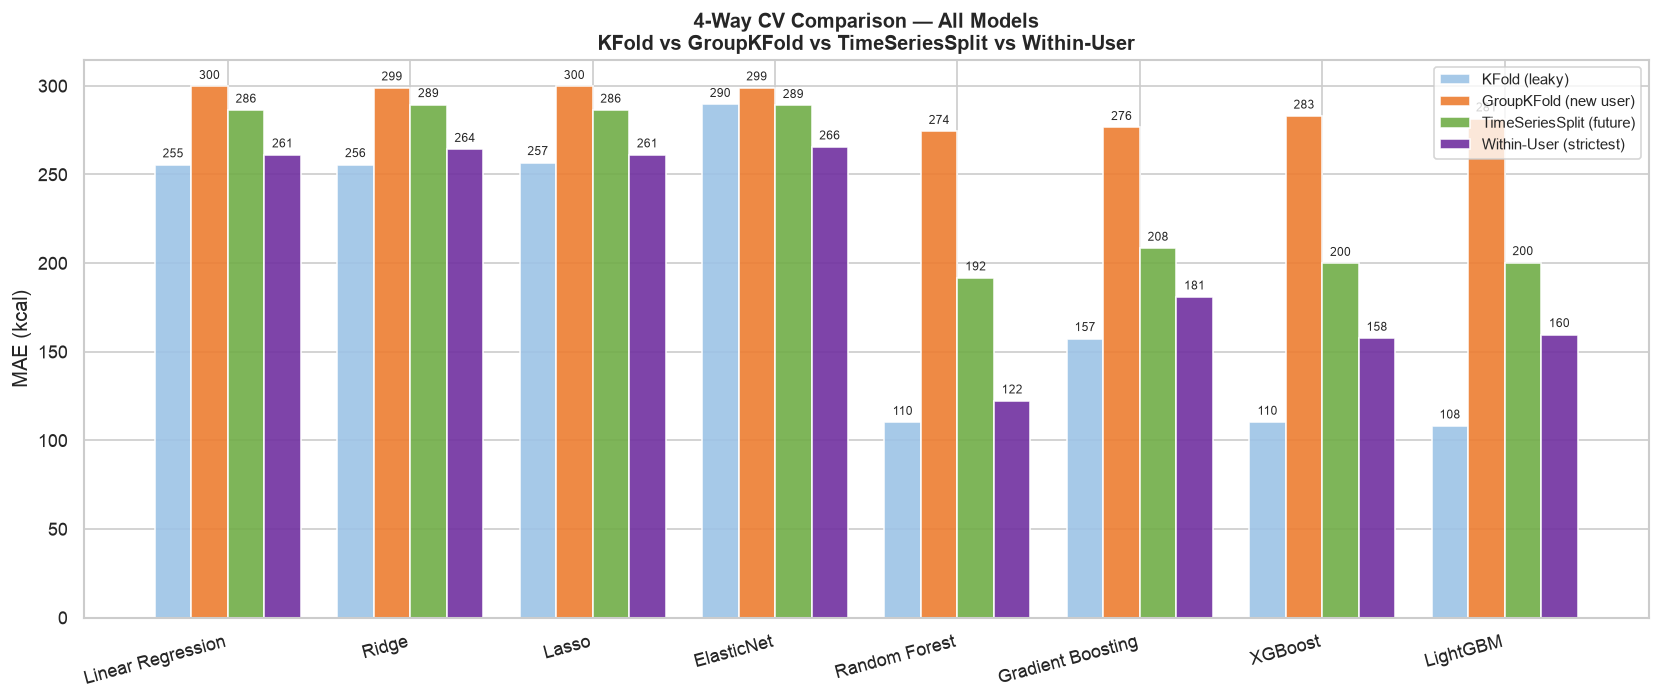

In [35]:
# ── 4-way comparison: KFold vs GKF vs TSCV vs Within-User ────────────────
rows = []
for name in default_models:
    rows.append({
        'Model':             name,
        'KFold MAE':         results[name]['MAE'],
        'GKF MAE (tuned)':   summary_df.loc[name, 'GKF MAE (GKF-tuned)'],
        'TSCV MAE (tuned)':  tscv_gkf_tuned[name][0],
        'Within-User MAE':   wu_gkf_tuned[name][0],
    })

cmp_wu = pd.DataFrame(rows).set_index('Model')
print('=== 4-Way CV Comparison ===')
print(cmp_wu.round(1).to_string())
print()
print('KFold       → leaky, optimistic')
print('GKF         → honest for NEW user')
print('TSCV        → honest, mixed users, future dates')
print('Within-User → strictest: same user, future dates only')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(cmp_wu))
width = 0.2

b1 = ax.bar(x - 1.5*width, cmp_wu['KFold MAE'],        width, label='KFold (leaky)',           color='#9DC3E6', alpha=0.9)
b2 = ax.bar(x - 0.5*width, cmp_wu['GKF MAE (tuned)'],  width, label='GroupKFold (new user)',    color='#ED7D31', alpha=0.9)
b3 = ax.bar(x + 0.5*width, cmp_wu['TSCV MAE (tuned)'], width, label='TimeSeriesSplit (future)', color='#70AD47', alpha=0.9)
b4 = ax.bar(x + 1.5*width, cmp_wu['Within-User MAE'],  width, label='Within-User (strictest)',  color='#7030A0', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(cmp_wu.index, rotation=15, ha='right')
ax.set_ylabel('MAE (kcal)')
ax.set_title('4-Way CV Comparison — All Models\n'
             'KFold vs GroupKFold vs TimeSeriesSplit vs Within-User',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
for bars in [b1, b2, b3, b4]:
    ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=7)
plt.tight_layout()
plt.show()

## 15. Per-User Model — Personalized Prediction

> 🔴 **Evaluation: Per-user train/test split (last 20% = test)**  
> Train a **separate model for each user** using only their own data.  
> Goal: *maximum personalization — does a dedicated model beat a shared one?*

| Approach | Train data | Personalization | Risk |
|---|---|---|---|
| Shared model (Sec 14) | All users | Low | Low |
| **Per-user model** | 1 user only | Maximum | Overfit (few rows) |

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def per_user_eval(model_obj, label=''):
    results_u = []
    for uid, grp in df.sort_values('date').groupby('id'):
        grp    = grp.reset_index(drop=True)
        n      = len(grp)
        n_test = max(1, int(n * 0.2))
        if n - n_test < 10:
            continue
        X_u = grp[['id'] + feature_cols]
        y_u = grp[target]
        X_tr, X_te = X_u.iloc[:-n_test], X_u.iloc[-n_test:]
        y_tr, y_te = y_u.iloc[:-n_test], y_u.iloc[-n_test:]
        pipe_u = make_pipe(model_obj)
        pipe_u.fit(X_tr, y_tr)
        y_pred = pipe_u.predict(X_te)
        results_u.append(mean_absolute_error(y_te, y_pred))
    mae = np.mean(results_u)
    if label:
        print(f'{label:<40} MAE={mae:.1f}  (n_users={len(results_u)})')
    return mae

print('Per-User evaluation — Default models:')
print('-' * 70)
pu_default = {}
for name, model in default_models.items():
    pu_default[name] = per_user_eval(model, f'{name} (default)')

print('\nPer-User evaluation — GKF-tuned models:')
print('-' * 70)
pu_gkf_tuned = {}
for name in default_models:
    pu_gkf_tuned[name] = per_user_eval(get_gkf_tuned_model(name), f'{name} (GKF-tuned)')

Per-User evaluation — Default models:
----------------------------------------------------------------------
Linear Regression (default)              MAE=70.4  (n_users=71)
Ridge (default)                          MAE=74.1  (n_users=71)
Lasso (default)                          MAE=71.3  (n_users=71)
ElasticNet (default)                     MAE=104.8  (n_users=71)
Random Forest (default)                  MAE=105.8  (n_users=71)
Gradient Boosting (default)              MAE=95.3  (n_users=71)
XGBoost (default)                        MAE=103.4  (n_users=71)
LightGBM (default)                       MAE=159.3  (n_users=71)

Per-User evaluation — GKF-tuned models:
----------------------------------------------------------------------
Linear Regression (GKF-tuned)            MAE=70.4  (n_users=71)
Ridge (GKF-tuned)                        MAE=93.5  (n_users=71)
Lasso (GKF-tuned)                        MAE=70.2  (n_users=71)
ElasticNet (GKF-tuned)                   MAE=71.3  (n_users=71)
Random 

=== 5-Way CV Comparison ===
                   KFold MAE  GKF MAE (tuned)  TSCV MAE (tuned)  Within-User MAE  Per-User MAE
Model                                                                                         
Linear Regression      255.4            299.6             286.3            261.0          70.4
Ridge                  255.6            298.8             289.4            264.2          93.5
Lasso                  256.7            299.6             286.3            261.1          70.2
ElasticNet             289.5            298.9             288.9            265.5          71.3
Random Forest          110.1            274.3             191.7            122.2         115.9
Gradient Boosting      157.4            276.5             208.4            180.9          88.9
XGBoost                110.2            282.9             199.8            157.6         110.9
LightGBM               108.1            281.4             200.3            159.7         294.7

KFold       → leaky, 

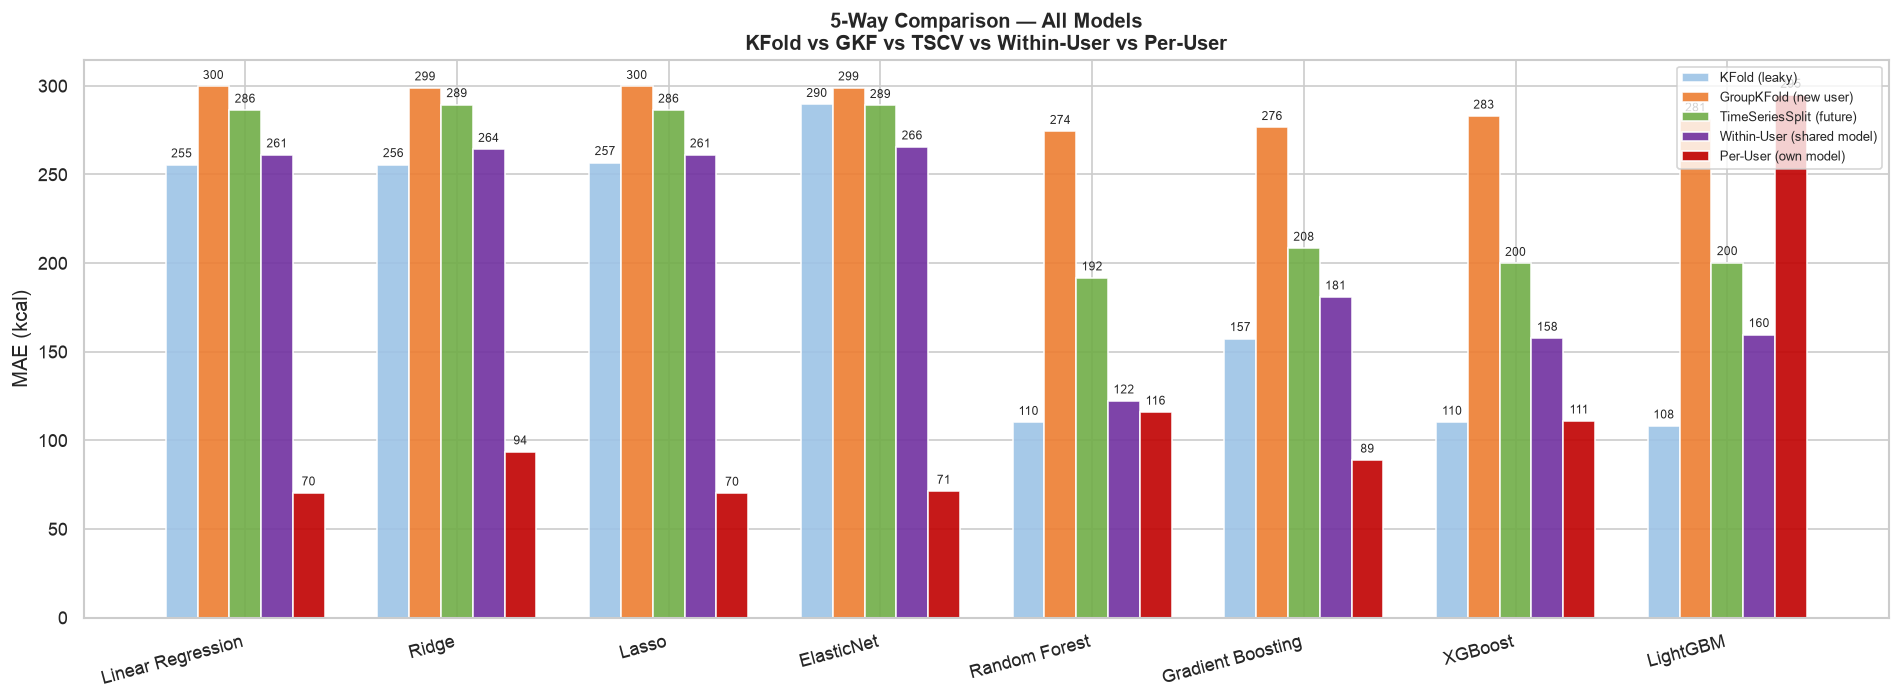

In [37]:
# ── 5-way comparison: KFold vs GKF vs TSCV vs Within-User vs Per-User ────
rows = []
for name in default_models:
    rows.append({
        'Model':              name,
        'KFold MAE':          results[name]['MAE'],
        'GKF MAE (tuned)':    summary_df.loc[name, 'GKF MAE (GKF-tuned)'],
        'TSCV MAE (tuned)':   tscv_gkf_tuned[name][0],
        'Within-User MAE':    wu_gkf_tuned[name][0],
        'Per-User MAE':       pu_gkf_tuned[name],
    })

cmp_pu = pd.DataFrame(rows).set_index('Model')
print('=== 5-Way CV Comparison ===')
print(cmp_pu.round(1).to_string())
print()
print('KFold       → leaky, optimistic')
print('GKF         → honest for NEW user')
print('TSCV        → honest, mixed users, future dates')
print('Within-User → same user, future dates (shared model)')
print('Per-User    → same user, future dates (own model per user)')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
x     = np.arange(len(cmp_pu))
width = 0.15

b1 = ax.bar(x - 2*width, cmp_pu['KFold MAE'],       width, label='KFold (leaky)',            color='#9DC3E6', alpha=0.9)
b2 = ax.bar(x - 1*width, cmp_pu['GKF MAE (tuned)'], width, label='GroupKFold (new user)',     color='#ED7D31', alpha=0.9)
b3 = ax.bar(x,           cmp_pu['TSCV MAE (tuned)'],width, label='TimeSeriesSplit (future)',  color='#70AD47', alpha=0.9)
b4 = ax.bar(x + 1*width, cmp_pu['Within-User MAE'], width, label='Within-User (shared model)',color='#7030A0', alpha=0.9)
b5 = ax.bar(x + 2*width, cmp_pu['Per-User MAE'],    width, label='Per-User (own model)',      color='#C00000', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(cmp_pu.index, rotation=15, ha='right')
ax.set_ylabel('MAE (kcal)')
ax.set_title('5-Way Comparison — All Models\n'
             'KFold vs GKF vs TSCV vs Within-User vs Per-User',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=8)
for bars in [b1, b2, b3, b4, b5]:
    ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=7)
plt.tight_layout()
plt.show()

## 16. Within-User & Per-User — TimeSeriesSplit CV (ปรับปรุงจาก single split)

> ใช้ **TimeSeriesSplit ต่อ user** แทน single 80/20 split เพื่อลด variance และให้ผลที่น่าเชื่อถือกว่า  
> แต่ละ user จะถูก evaluate หลาย fold โดยเรียงตามวันที่ (temporal order)


In [38]:
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS  = 3
MIN_TRAIN = 15
MIN_TEST  = 5
tscv_user = TimeSeriesSplit(n_splits=N_SPLITS)

# ─────────────────────────────────────────────────────────────────
# A) Within-User + TimeSeriesSplit CV  (retrain per fold — no leakage)
# ─────────────────────────────────────────────────────────────────
def wu_tscv_eval(model_obj, label=''):
    """Retrain model on each temporal fold's training set → no leakage."""
    df_sorted_wu = df.sort_values('date').reset_index(drop=True)
    X_all = df_sorted_wu[['id'] + feature_cols]
    y_all = df_sorted_wu[target]

    fold_maes, fold_rmses = [], []
    for tr_idx, te_idx in tscv_user.split(df_sorted_wu):
        if len(tr_idx) < MIN_TRAIN or len(te_idx) < MIN_TEST:
            continue
        pipe = make_pipe(model_obj)
        pipe.fit(X_all.iloc[tr_idx], y_all.iloc[tr_idx])
        y_pred = pipe.predict(X_all.iloc[te_idx])
        fold_maes.append(mean_absolute_error(y_all.iloc[te_idx], y_pred))
        fold_rmses.append(np.sqrt(mean_squared_error(y_all.iloc[te_idx], y_pred)))

    mae  = np.mean(fold_maes)
    rmse = np.mean(fold_rmses)
    print(f'{label:<45} MAE={mae:.1f}  RMSE={rmse:.1f}  (folds={len(fold_maes)})')
    return mae, rmse

print('=== Within-User + TimeSeriesSplit CV (retrain per fold) ===')
wu_tscv = {}
for name, model in default_models.items():
    wu_tscv[name] = wu_tscv_eval(model, label=name)

print()

# ─────────────────────────────────────────────────────────────────
# B) Per-User + TimeSeriesSplit CV  (separate model per user)
# ─────────────────────────────────────────────────────────────────
def per_user_tscv_eval(model_obj, label=''):
    fold_maes, fold_rmses = [], []
    skipped_users = 0

    for uid, grp in df.sort_values('date').groupby('id'):
        grp = grp.reset_index(drop=True)
        X_u = grp[['id'] + feature_cols]
        y_u = grp[target]

        user_folds = 0
        for tr_idx, te_idx in tscv_user.split(grp):
            if len(tr_idx) < MIN_TRAIN or len(te_idx) < MIN_TEST:
                continue
            pipe_u = make_pipe(model_obj)
            pipe_u.fit(X_u.iloc[tr_idx], y_u.iloc[tr_idx])
            y_pred = pipe_u.predict(X_u.iloc[te_idx])
            fold_maes.append(mean_absolute_error(y_u.iloc[te_idx], y_pred))
            fold_rmses.append(np.sqrt(mean_squared_error(y_u.iloc[te_idx], y_pred)))
            user_folds += 1

        if user_folds == 0:
            skipped_users += 1

    mae  = np.mean(fold_maes)
    rmse = np.mean(fold_rmses)
    print(f'{label:<45} MAE={mae:.1f}  RMSE={rmse:.1f}  (folds={len(fold_maes)}, skipped_users={skipped_users})')
    return mae, rmse

print('=== Per-User + TimeSeriesSplit CV (separate model per user) ===')
pu_tscv = {}
for name, model in default_models.items():
    pu_tscv[name] = per_user_tscv_eval(model, label=name)

print()

# ─────────────────────────────────────────────────────────────────
# C) เปรียบเทียบ single split vs TimeSeriesSplit CV  (MAE & RMSE เท่านั้น)
# ─────────────────────────────────────────────────────────────────
print('=== MAE Comparison: Single Split vs TimeSeriesSplit CV ===')
print(f'{"Model":<30} {"WU-Single":>10} {"WU-TSCV":>10} {"PU-Single":>10} {"PU-TSCV":>10}')
print('-' * 75)
for name in default_models:
    wu_s  = wu_default[name][0]            if name in wu_default else float('nan')
    wu_cv = wu_tscv[name][0]               if name in wu_tscv    else float('nan')
    pu_s  = pu_default.get(name, float('nan'))
    pu_cv = pu_tscv[name][0]               if name in pu_tscv    else float('nan')
    print(f'{name:<30} {wu_s:>10.1f} {wu_cv:>10.1f} {pu_s:>10.1f} {pu_cv:>10.1f}')


=== Within-User + TimeSeriesSplit CV (retrain per fold) ===
Linear Regression                             MAE=286.3  RMSE=369.3  (folds=3)
Ridge                                         MAE=286.5  RMSE=369.4  (folds=3)
Lasso                                         MAE=287.1  RMSE=369.8  (folds=3)
ElasticNet                                    MAE=308.0  RMSE=383.7  (folds=3)
Random Forest                                 MAE=178.5  RMSE=298.5  (folds=3)
Gradient Boosting                             MAE=197.7  RMSE=301.1  (folds=3)
XGBoost                                       MAE=170.6  RMSE=287.9  (folds=3)
LightGBM                                      MAE=170.3  RMSE=288.1  (folds=3)

=== Per-User + TimeSeriesSplit CV (separate model per user) ===
Linear Regression                             MAE=118.7  RMSE=162.9  (folds=213, skipped_users=0)
Ridge                                         MAE=77.0  RMSE=114.5  (folds=213, skipped_users=0)
Lasso                                         MA

=== 7-Way Strategy Comparison (MAE) ===
                   KFold  GroupKFold   TSCV  WU-Single  WU-TSCV  PU-Single  PU-TSCV
Model                                                                              
Linear Regression  255.4       299.6  286.3      261.0    286.3       70.4    118.7
Ridge              255.6       298.8  289.4      264.2    286.5       93.5     77.0
Lasso              256.7       299.6  286.3      261.1    287.1       70.2     70.4
ElasticNet         289.5       298.9  288.9      265.5    308.0       71.3    101.9
Random Forest      110.1       274.3  191.7      122.2    178.5      115.9    115.6
Gradient Boosting  157.4       276.5  208.4      180.9    197.7       88.9    101.4
XGBoost            110.2       282.9  199.8      157.6    170.6      110.9    117.4
LightGBM           108.1       281.4  200.3      159.7    170.3      294.7    259.6

KFold      → leaky, optimistic (users mixed across folds)
GroupKFold → honest for NEW user prediction
TSCV       → hone

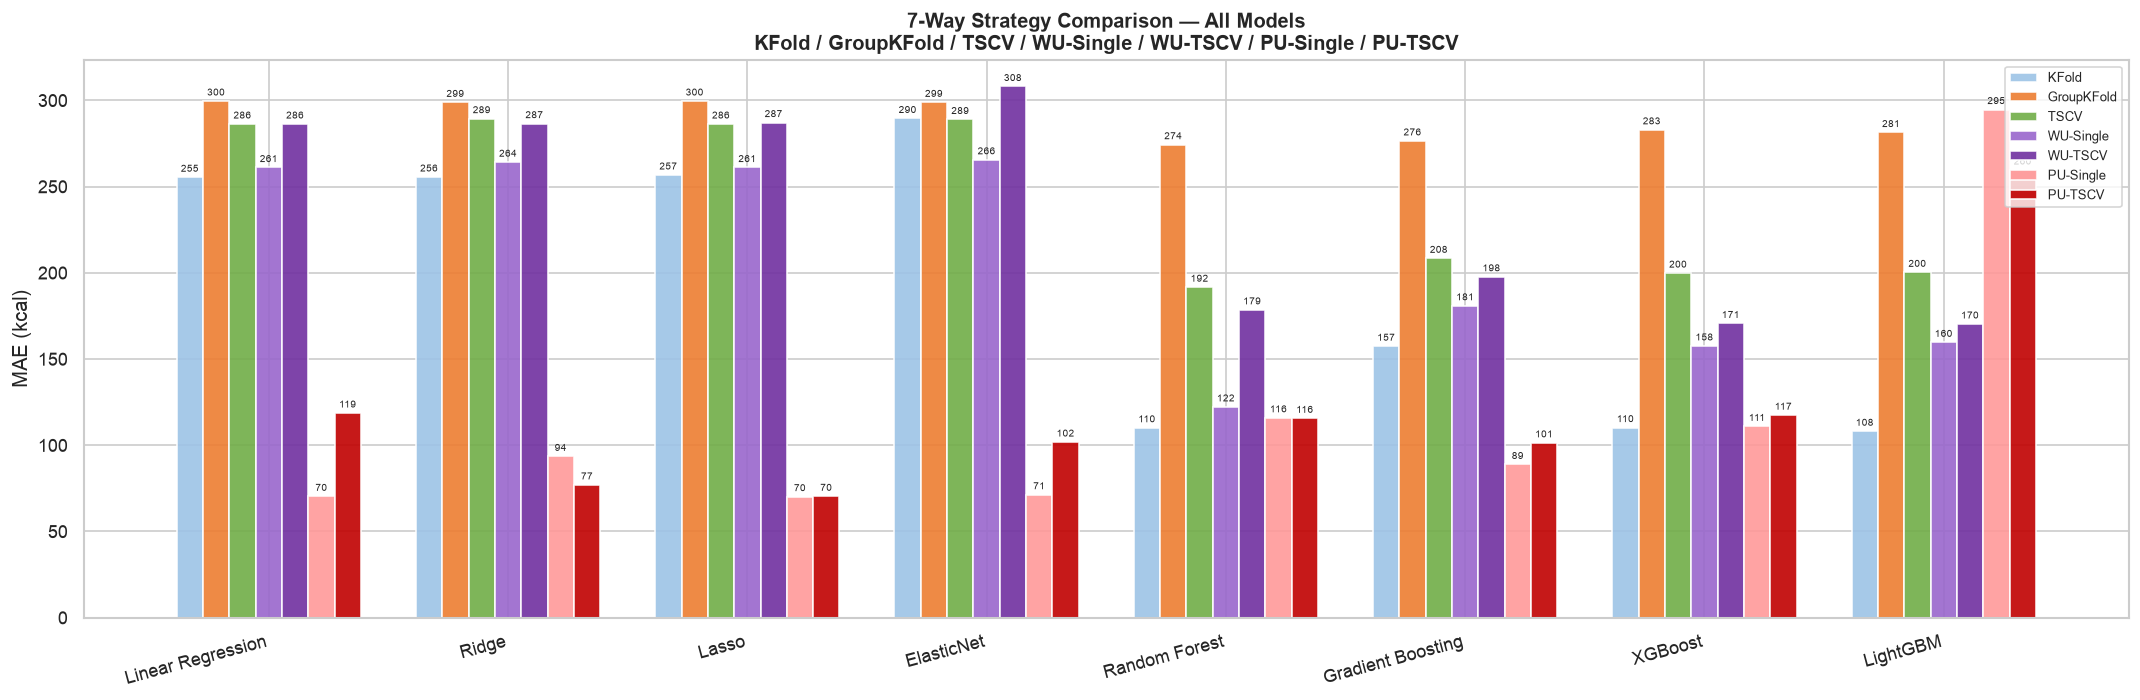

In [39]:
# ── 7-Way Strategy Comparison — All Strategies รวมกัน ──────────────────────
rows = []
for name in default_models:
    rows.append({
        'Model':          name,
        'KFold':          results[name]['MAE'],
        'GroupKFold':     summary_df.loc[name, 'GKF MAE (GKF-tuned)'],
        'TSCV':           tscv_gkf_tuned[name][0],
        'WU-Single':      wu_gkf_tuned[name][0],
        'WU-TSCV':        wu_tscv[name][0],
        'PU-Single':      pu_gkf_tuned[name],
        'PU-TSCV':        pu_tscv[name][0],
    })

all_cmp = pd.DataFrame(rows).set_index('Model')
print('=== 7-Way Strategy Comparison (MAE) ===')
print(all_cmp.round(1).to_string())
print()
print('KFold      → leaky, optimistic (users mixed across folds)')
print('GroupKFold → honest for NEW user prediction')
print('TSCV       → honest, future dates, mixed users')
print('WU-Single  → same user, future dates, shared model (single split)')
print('WU-TSCV    → same user, future dates, shared model (CV per fold)')
print('PU-Single  → same user, own model per user (single split)')
print('PU-TSCV    → same user, own model per user (CV per fold) ← most reliable')

# ── Plot ──────────────────────────────────────────────────────────────────
strategies = ['KFold', 'GroupKFold', 'TSCV', 'WU-Single', 'WU-TSCV', 'PU-Single', 'PU-TSCV']
colors     = ['#9DC3E6', '#ED7D31', '#70AD47', '#9966CC', '#7030A0', '#FF9999', '#C00000']

fig, ax = plt.subplots(figsize=(18, 6))
x     = np.arange(len(all_cmp))
width = 0.11

bars_list = []
for i, (strat, color) in enumerate(zip(strategies, colors)):
    offset = (i - len(strategies) / 2 + 0.5) * width
    b = ax.bar(x + offset, all_cmp[strat], width, label=strat, color=color, alpha=0.9)
    bars_list.append(b)
    ax.bar_label(b, fmt='%.0f', padding=2, fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels(all_cmp.index, rotation=15, ha='right')
ax.set_ylabel('MAE (kcal)')
ax.set_title('7-Way Strategy Comparison — All Models\n'
             'KFold / GroupKFold / TSCV / WU-Single / WU-TSCV / PU-Single / PU-TSCV',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()


## 17. LOSO — Leave-One-Subject-Out Evaluation

> **LOSO (Leave-One-Subject-Out)**: train บน **n-1 users**, test บน **1 user** วนครบทุก user  
> เป็น cross-validation ที่เข้มงวดที่สุดสำหรับ **generalisation ไปยัง user ใหม่**  
> แต่ละรอบ: ไม่มีข้อมูลของ test-user รั่วไหลเข้า training เลย


Total users: 71
Running LOSO (71 folds) ...
=== LOSO Evaluation (MAE / RMSE / R²) ===
                            MAE     RMSE       R2
--------------------------------------------------
Linear Regression         282.7    333.3   -0.176
Ridge                     284.0    331.8   -0.192
Lasso                     282.7    333.3   -0.176
ElasticNet                285.1    331.4   -0.205
Random Forest             266.2    308.2   -0.221
Gradient Boosting         278.8    322.4   -0.293
XGBoost                   274.5    316.2   -0.219
LightGBM                  277.4    319.8   -0.250
=== Per-User MAE (best model highlighted) ===
Best model (lowest avg MAE): Random Forest (266.2 kcal)
                          Linear Regression  Ridge  Lasso  ElasticNet  Random Forest  Gradient Boosting  XGBoost  LightGBM
user_id                                                                                                                   
621e2e8e67b776a24055b564              245.8  253.0  245.8       2

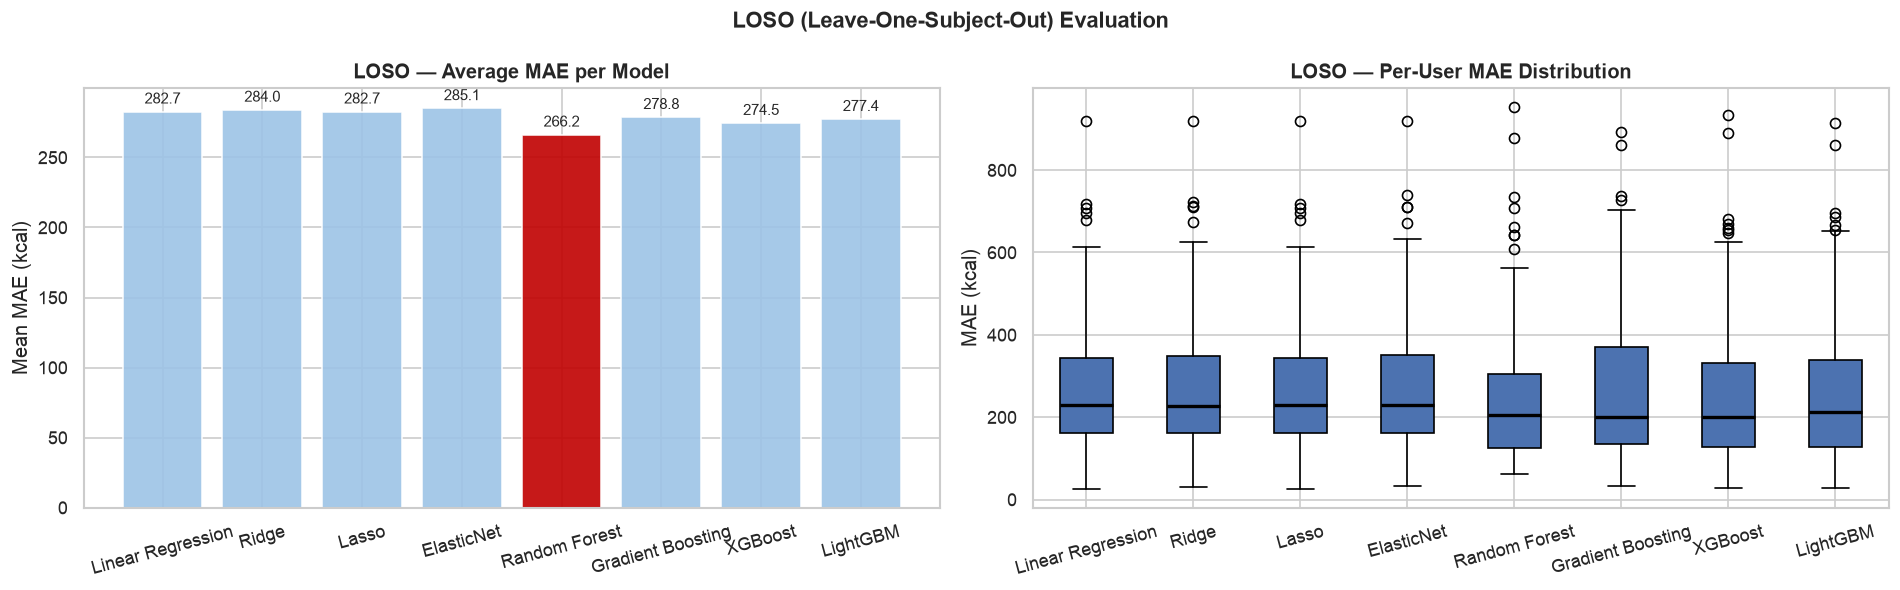

=== LOSO vs Other Strategies (MAE) ===
                   GroupKFold  WU-TSCV  PU-TSCV   LOSO
Model                                                 
Linear Regression       299.6    286.3    118.7  282.7
Ridge                   298.8    286.5     77.0  284.0
Lasso                   299.6    287.1     70.4  282.7
ElasticNet              298.9    308.0    101.9  285.1
Random Forest           274.3    178.5    115.6  266.2
Gradient Boosting       276.5    197.7    101.4  278.8
XGBoost                 282.9    170.6    117.4  274.5
LightGBM                281.4    170.3    259.6  277.4

GroupKFold → 3-fold, users split across folds (may share users)
WU-TSCV    → within-user temporal CV, shared model
PU-TSCV    → per-user model, temporal CV
LOSO       → strictest: train on ALL other users, test on 1 new user


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ─────────────────────────────────────────────────────────────────
# LOSO — Leave-One-Subject-Out
# train on n-1 users, test on 1 user, repeat for every user
# ─────────────────────────────────────────────────────────────────
unique_users = df['id'].unique()
print(f'Total users: {len(unique_users)}')
print(f'Running LOSO ({len(unique_users)} folds) ...')

loso_results = {name: {'maes': [], 'rmses': [], 'r2s': []} for name in default_models}

for test_user in unique_users:
    train_mask = df['id'] != test_user
    test_mask  = df['id'] == test_user

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    if len(X_test) == 0:
        continue

    for name in default_models:
        pipe = make_pipe(get_gkf_tuned_model(name))
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        ss_res = np.sum((y_test - y_pred) ** 2)
        ss_tot = np.sum((y_test - y_test.mean()) ** 2)
        r2   = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

        loso_results[name]['maes'].append(mae)
        loso_results[name]['rmses'].append(rmse)
        loso_results[name]['r2s'].append(r2)

# ── Summary table ────────────────────────────────────────────────
print('=== LOSO Evaluation (MAE / RMSE / R²) ===')
print(f'{"": <22} {"MAE":>8} {"RMSE":>8} {"R2":>8}')
print('-' * 50)
loso_summary = {}
for name in default_models:
    maes  = loso_results[name]['maes']
    rmses = loso_results[name]['rmses']
    r2s   = [v for v in loso_results[name]['r2s'] if not np.isnan(v)]
    avg_mae  = np.mean(maes)
    avg_rmse = np.mean(rmses)
    avg_r2   = np.mean(r2s) if r2s else float('nan')
    loso_summary[name] = (avg_mae, avg_rmse, avg_r2)
    print(f'{name:<22} {avg_mae:>8.1f} {avg_rmse:>8.1f} {avg_r2:>8.3f}')

# ── Per-user detail ──────────────────────────────────────────────
print('=== Per-User MAE (best model highlighted) ===')
best_model = min(loso_summary, key=lambda n: loso_summary[n][0])
print(f'Best model (lowest avg MAE): {best_model} ({loso_summary[best_model][0]:.1f} kcal)')

per_user_df = pd.DataFrame(
    {name: loso_results[name]['maes'] for name in default_models},
    index=unique_users
)
per_user_df.index.name = 'user_id'
print(per_user_df.round(1).to_string())

# ── Plot: avg MAE per model ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: avg MAE bar chart
model_names = list(default_models.keys())
avg_maes    = [loso_summary[n][0] for n in model_names]
bar_colors  = ['#C00000' if n == best_model else '#9DC3E6' for n in model_names]
bars = axes[0].bar(model_names, avg_maes, color=bar_colors, alpha=0.9)
axes[0].bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
axes[0].set_ylabel('Mean MAE (kcal)')
axes[0].set_title('LOSO — Average MAE per Model', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Right: per-user MAE box plot
axes[1].boxplot(
    [loso_results[n]['maes'] for n in model_names],
    tick_labels=model_names, patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
axes[1].set_ylabel('MAE (kcal)')
axes[1].set_title('LOSO — Per-User MAE Distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('LOSO (Leave-One-Subject-Out) Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Compare LOSO vs other strategies ────────────────────────────
print('=== LOSO vs Other Strategies (MAE) ===')
compare_rows = []
for name in default_models:
    compare_rows.append({
        'Model':      name,
        'GroupKFold': summary_df.loc[name, 'GKF MAE (GKF-tuned)'],
        'WU-TSCV':    wu_tscv[name][0],
        'PU-TSCV':    pu_tscv[name][0],
        'LOSO':       loso_summary[name][0],
    })
loso_cmp = pd.DataFrame(compare_rows).set_index('Model')
print(loso_cmp.round(1).to_string())
print()
print('GroupKFold → 3-fold, users split across folds (may share users)')
print('WU-TSCV    → within-user temporal CV, shared model')
print('PU-TSCV    → per-user model, temporal CV')
print('LOSO       → strictest: train on ALL other users, test on 1 new user')


### 8-Way Strategy Comparison — Including LOSO

> รวม LOSO เข้ากับ 7 strategies เดิม เพื่อเปรียบเทียบครบทุกวิธี

=== 8-Way Strategy Comparison (MAE) ===
                   KFold  GroupKFold   TSCV  WU-Single  WU-TSCV  PU-Single  PU-TSCV   LOSO
Model                                                                                     
Linear Regression  255.4       299.6  286.3      261.0    286.3       70.4    118.7  282.7
Ridge              255.6       298.8  289.4      264.2    286.5       93.5     77.0  284.0
Lasso              256.7       299.6  286.3      261.1    287.1       70.2     70.4  282.7
ElasticNet         289.5       298.9  288.9      265.5    308.0       71.3    101.9  285.1
Random Forest      110.1       274.3  191.7      122.2    178.5      115.9    115.6  266.2
Gradient Boosting  157.4       276.5  208.4      180.9    197.7       88.9    101.4  278.8
XGBoost            110.2       282.9  199.8      157.6    170.6      110.9    117.4  274.5
LightGBM           108.1       281.4  200.3      159.7    170.3      294.7    259.6  277.4


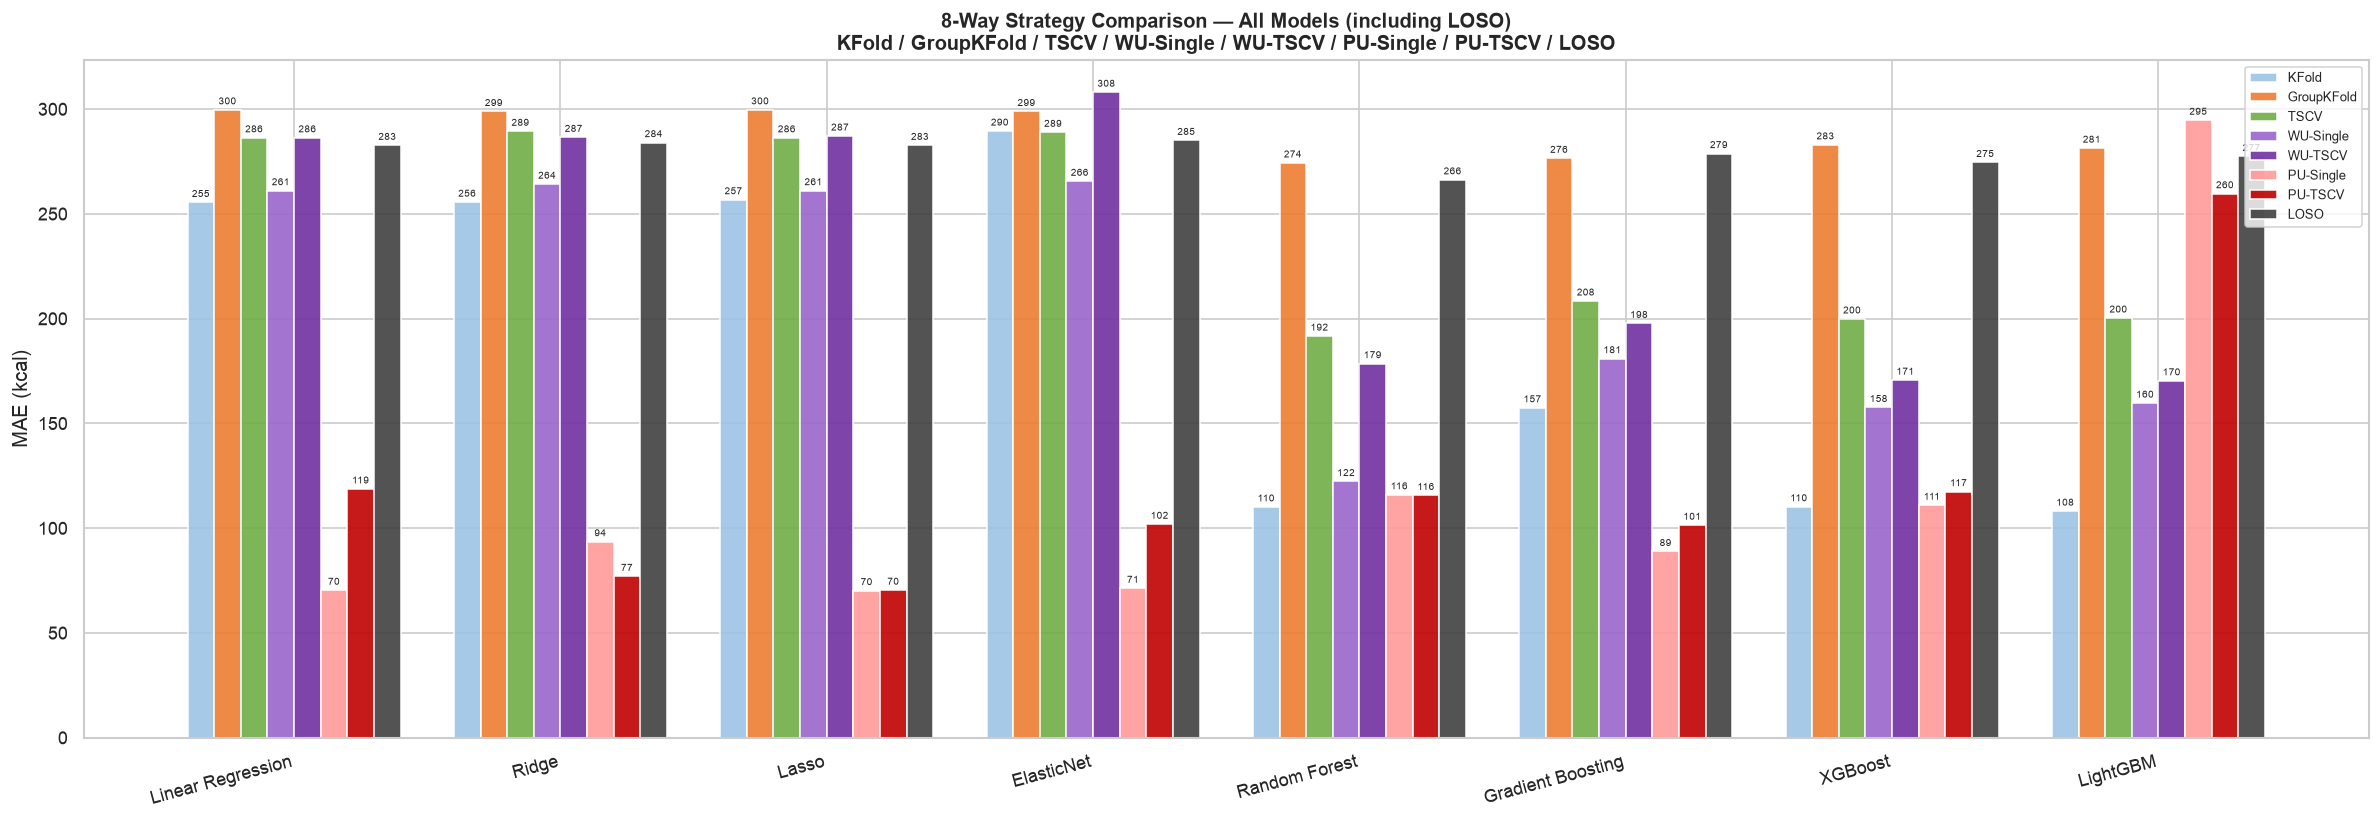


KFold      → leaky ❌
GroupKFold → new user (shared model)
TSCV       → future dates, mixed users
WU-Single  → same user, future dates, shared model
WU-TSCV    → same user, future dates, shared model (CV)
PU-Single  → per-user model
PU-TSCV    → per-user model (CV)
LOSO       → strictest new-user test ← train on ALL others, test on 1


In [45]:
# ── 8-Way Strategy Comparison — รวม LOSO ─────────────────────────────────
rows_8 = []
for name in default_models:
    rows_8.append({
        'Model':      name,
        'KFold':      results[name]['MAE'],
        'GroupKFold': summary_df.loc[name, 'GKF MAE (GKF-tuned)'],
        'TSCV':       tscv_gkf_tuned[name][0],
        'WU-Single':  wu_gkf_tuned[name][0],
        'WU-TSCV':    wu_tscv[name][0],
        'PU-Single':  pu_gkf_tuned[name],
        'PU-TSCV':    pu_tscv[name][0],
        'LOSO':       loso_summary[name][0],
    })

all_cmp_8 = pd.DataFrame(rows_8).set_index('Model')
print('=== 8-Way Strategy Comparison (MAE) ===')
print(all_cmp_8.round(1).to_string())

# ── Plot ──────────────────────────────────────────────────────────────────
strategies = ['KFold', 'GroupKFold', 'TSCV', 'WU-Single', 'WU-TSCV', 'PU-Single', 'PU-TSCV', 'LOSO']
colors     = ['#9DC3E6', '#ED7D31', '#70AD47', '#9966CC', '#7030A0', '#FF9999', '#C00000', '#404040']

fig, ax = plt.subplots(figsize=(20, 7))
x     = np.arange(len(all_cmp_8))
width = 0.10

for i, (strat, color) in enumerate(zip(strategies, colors)):
    offset = (i - len(strategies) / 2 + 0.5) * width
    b = ax.bar(x + offset, all_cmp_8[strat], width, label=strat, color=color, alpha=0.9)
    ax.bar_label(b, fmt='%.0f', padding=2, fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels(all_cmp_8.index, rotation=15, ha='right')
ax.set_ylabel('MAE (kcal)')
ax.set_title('8-Way Strategy Comparison — All Models (including LOSO)\n'
             'KFold / GroupKFold / TSCV / WU-Single / WU-TSCV / PU-Single / PU-TSCV / LOSO',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

print()
print('KFold      → leaky ❌')
print('GroupKFold → new user (shared model)')
print('TSCV       → future dates, mixed users')
print('WU-Single  → same user, future dates, shared model')
print('WU-TSCV    → same user, future dates, shared model (CV)')
print('PU-Single  → per-user model')
print('PU-TSCV    → per-user model (CV)')
print('LOSO       → strictest new-user test ← train on ALL others, test on 1')


## 19. Drop High-Missing Features — 19 vs 15 Features

> ทดสอบว่าถ้า drop features ที่ missing > 50% (nremhr, rmssd, ALERT, TIRED) ออก
> MAE จะแย่ลงไหม ถ้าไม่แย่ = 15 features พอ

In [46]:
# ── แบบ A: 19 features (ปัจจุบัน) vs แบบ B: 15 features (drop missing > 50%) ──
drop_cols = ['nremhr', 'rmssd', 'ALERT', 'TIRED']
feature_cols_B = [f for f in feature_cols if f not in drop_cols]
X_B = df[['id'] + feature_cols_B]

print(f"แบบ A: {len(feature_cols)} features")
print(f"แบบ B: {len(feature_cols_B)} features (drop: {drop_cols})")
print()

results_AB = {}
for label, pipe_model, X_input in [
    ('A — 19 features', make_pipe(get_gkf_tuned_model('XGBoost')), X),
    ('B — 15 features', make_pipe(get_gkf_tuned_model('XGBoost')), X_B),
]:
    cv = cross_validate(pipe_model, X_input, y, cv=gkf, groups=groups, n_jobs=2,
                        scoring={'mae': 'neg_mean_absolute_error',
                                 'rmse': 'neg_mean_squared_error', 'r2': 'r2'})
    mae  = -cv['test_mae'].mean()
    rmse = np.sqrt(-cv['test_rmse'].mean())
    r2   = cv['test_r2'].mean()
    results_AB[label] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{label}: MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}")

print()
diff = results_AB['B — 15 features']['MAE'] - results_AB['A — 19 features']['MAE']
if abs(diff) < 5:
    print(f"MAE ต่างกัน {diff:+.1f} kcal → เล็กน้อยมาก ✅ ใช้ 15 features ได้")
else:
    print(f"MAE ต่างกัน {diff:+.1f} kcal → ต่างพอสมควร ⚠️ ควรเก็บ 19 features ไว้")


แบบ A: 19 features
แบบ B: 15 features (drop: ['nremhr', 'rmssd', 'ALERT', 'TIRED'])

A — 19 features: MAE=282.9  RMSE=419.1  R²=0.643
B — 15 features: MAE=283.9  RMSE=419.9  R²=0.642

MAE ต่างกัน +1.0 kcal → เล็กน้อยมาก ✅ ใช้ 15 features ได้


## 19b. 8-Way Strategy Comparison — 15 Features vs 19 Features

> ทดสอบ 15 features (drop nremhr, rmssd, ALERT, TIRED) กับทุก CV strategy แล้วเทียบกับ 19 features

19 features: 19  →  15 features: 15
Dropped: ['nremhr', 'rmssd', 'ALERT', 'TIRED']

=== 15-feature: all strategies (XGBoost GKF-tuned params) ===
  Linear Regression
  Ridge
  Lasso
  ElasticNet
  Random Forest
  Gradient Boosting
  XGBoost
  LightGBM
=== 19 features ===
                   KFold  GroupKFold   TSCV  WU-Single  WU-TSCV  PU-Single  PU-TSCV   LOSO
Linear Regression  255.4       299.6  286.3      261.0    286.3       70.4    118.7  282.7
Ridge              255.6       298.8  289.4      264.2    286.5       93.5     77.0  284.0
Lasso              256.7       299.6  286.3      261.1    287.1       70.2     70.4  282.7
ElasticNet         289.5       298.9  288.9      265.5    308.0       71.3    101.9  285.1
Random Forest      110.1       274.3  191.7      122.2    178.5      115.9    115.6  266.2
Gradient Boosting  157.4       276.5  208.4      180.9    197.7       88.9    101.4  278.8
XGBoost            110.2       282.9  199.8      157.6    170.6      110.9    117.4  274.5


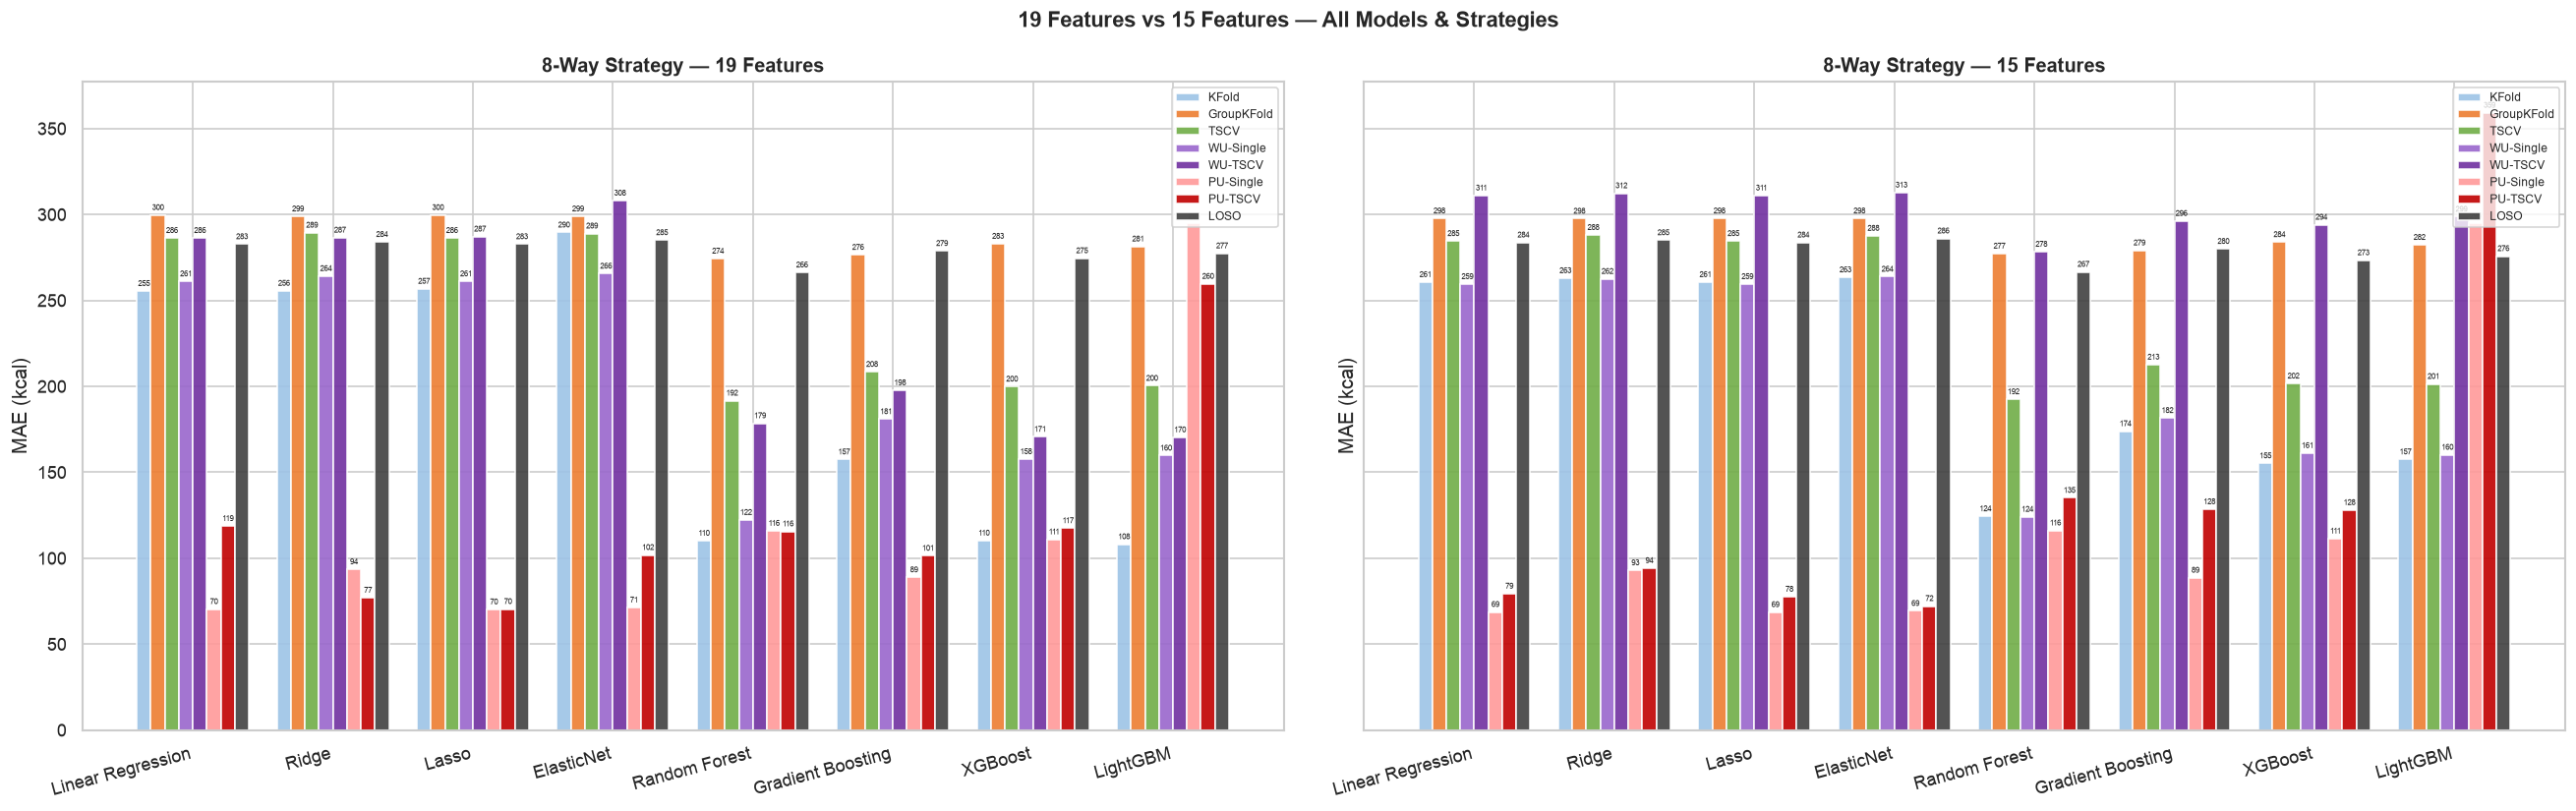

In [50]:
# ── 15-feature set ───────────────────────────────────────────────────────────
drop_cols_15 = ["nremhr", "rmssd", "ALERT", "TIRED"]
fc15 = [f for f in feature_cols if f not in drop_cols_15]
X15  = df[["id"] + fc15]
print(f"19 features: {len(feature_cols)}  →  15 features: {len(fc15)}")
print(f"Dropped: {drop_cols_15}")
print()

def make_pipe15(model):
    return Pipeline([
        ("imputer", PerUserMedianImputer(feature_cols=fc15)),
        ("scaler",  StandardScaler()),
        ("model",   model),
    ])

# ── helper ───────────────────────────────────────────────────────────────────
def eval_strategy(pipe_fn, cv_obj, X_input, groups_input=None, label=""):
    kw = dict(scoring={"mae": "neg_mean_absolute_error", "rmse": "neg_mean_squared_error", "r2": "r2"}, n_jobs=2)
    if groups_input is not None:
        res = cross_validate(pipe_fn, X_input, y, cv=cv_obj, groups=groups_input, **kw)
    else:
        res = cross_validate(pipe_fn, X_input, y, cv=cv_obj, **kw)
    mae  = -res["test_mae"].mean()
    rmse = np.sqrt(-res["test_rmse"].mean())
    r2   = res["test_r2"].mean()
    if label: print(f"  {label:<35} MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}")
    return mae, rmse, r2

best_name = min(loso_summary, key=lambda n: loso_summary[n][0])  # reuse GKF-tuned model

# ── 8 strategies with 15 features ────────────────────────────────────────────
kf3    = KFold(n_splits=3, shuffle=True, random_state=42)
gkf3   = GroupKFold(n_splits=3)
tscv3  = TimeSeriesSplit(n_splits=3)

res15 = {}
print("=== 15-feature: all strategies (XGBoost GKF-tuned params) ===")
for name in default_models:
    m = get_gkf_tuned_model(name)
    kf_mae,_,_   = eval_strategy(make_pipe15(m), kf3,   X15)
    gkf_mae,_,_  = eval_strategy(make_pipe15(m), gkf3,  X15, groups)
    # TSCV
    X15_sorted = df.sort_values("date").reset_index(drop=True)[["id"]+fc15]
    y_sorted15 = df.sort_values("date").reset_index(drop=True)["calories"]
    tscv_res   = cross_validate(make_pipe15(m), X15_sorted, y_sorted15, cv=tscv3, n_jobs=2,
                                scoring={"mae":"neg_mean_absolute_error"})
    tscv_mae   = -tscv_res["test_mae"].mean()
    # WU-Single
    df_s = df.sort_values(["id","date"]).reset_index(drop=True)
    tr_wu, te_wu = [], []
    for uid, grp in df_s.groupby("id"):
        n = len(grp); nt = max(1, int(n*0.2))
        tr_wu.extend(grp.index[:-nt].tolist()); te_wu.extend(grp.index[-nt:].tolist())
    X15s = df_s[["id"]+fc15]; y15s = df_s["calories"]
    p = make_pipe15(get_gkf_tuned_model(name)); p.fit(X15s.iloc[tr_wu], y15s.iloc[tr_wu])
    wu_single = mean_absolute_error(y15s.iloc[te_wu], p.predict(X15s.iloc[te_wu]))
    # WU-TSCV
    tscv_u = TimeSeriesSplit(n_splits=3)
    wu_folds = []
    for tr, te in tscv_u.split(df_s):
        if len(tr)<15 or len(te)<5: continue
        pp = make_pipe15(get_gkf_tuned_model(name)); pp.fit(X15s.iloc[tr], y15s.iloc[tr])
        wu_folds.append(mean_absolute_error(y15s.iloc[te], pp.predict(X15s.iloc[te])))
    wu_tscv15 = float(np.mean(wu_folds))
    # PU-Single
    pu_maes = []
    for uid, grp in df.sort_values("date").groupby("id"):
        grp = grp.reset_index(drop=True)
        n = len(grp); nt = max(1,int(n*0.2))
        if n-nt < 10: continue
        Xu = grp[["id"]+fc15]; yu = grp["calories"]
        pp = make_pipe15(get_gkf_tuned_model(name)); pp.fit(Xu.iloc[:-nt], yu.iloc[:-nt])
        pu_maes.append(mean_absolute_error(yu.iloc[-nt:], pp.predict(Xu.iloc[-nt:])))
    pu_single15 = float(np.mean(pu_maes))
    # PU-TSCV
    pu_tscv_maes = []
    for uid, grp in df.sort_values("date").groupby("id"):
        grp = grp.reset_index(drop=True)
        Xu = grp[["id"]+fc15]; yu = grp["calories"]
        for tr, te in tscv_u.split(grp):
            if len(tr)<15 or len(te)<5: continue
            pp = make_pipe15(get_gkf_tuned_model(name)); pp.fit(Xu.iloc[tr], yu.iloc[tr])
            pu_tscv_maes.append(mean_absolute_error(yu.iloc[te], pp.predict(Xu.iloc[te])))
    pu_tscv15 = float(np.mean(pu_tscv_maes))
    # LOSO
    loso_maes = []
    for test_user in df["id"].unique():
        tr_m = df["id"] != test_user; te_m = df["id"] == test_user
        pp = make_pipe15(get_gkf_tuned_model(name))
        pp.fit(X15[tr_m], y[tr_m])
        loso_maes.append(mean_absolute_error(y[te_m], pp.predict(X15[te_m])))
    loso15 = float(np.mean(loso_maes))
    res15[name] = (kf_mae, gkf_mae, tscv_mae, wu_single, wu_tscv15, pu_single15, pu_tscv15, loso15)
    print(f"  {name}")

# ── Comparison table ─────────────────────────────────────────────────────────
strat_names = ["KFold","GroupKFold","TSCV","WU-Single","WU-TSCV","PU-Single","PU-TSCV","LOSO"]
df15 = pd.DataFrame(res15, index=strat_names).T
df19 = pd.DataFrame({
    name: [
        results[name]["MAE"],
        summary_df.loc[name, "GKF MAE (GKF-tuned)"],
        tscv_gkf_tuned[name][0],
        wu_gkf_tuned[name][0],
        wu_tscv[name][0],
        pu_gkf_tuned[name],
        pu_tscv[name][0],
        loso_summary[name][0],
    ] for name in default_models
}, index=strat_names).T

diff = df15 - df19
print("=== 19 features ===")
print(df19.round(1).to_string())
print("=== 15 features ===")
print(df15.round(1).to_string())
print("=== Difference (15 - 19), + = worse ===")
print(diff.round(1).to_string())

# ── Plot: side-by-side 8-Way for 19 vs 15 features ──────────────────────────
colors_8 = ["#9DC3E6","#ED7D31","#70AD47","#9966CC","#7030A0","#FF9999","#C00000","#404040"]
fig, axes = plt.subplots(1, 2, figsize=(22, 7), sharey=True)
for ax, data, title in zip(axes, [df19, df15], ["19 Features", "15 Features"]):
    x = np.arange(len(data)); width = 0.10
    for i, (strat, color) in enumerate(zip(strat_names, colors_8)):
        offset = (i - len(strat_names)/2 + 0.5) * width
        b = ax.bar(x + offset, data[strat], width, label=strat, color=color, alpha=0.9)
        ax.bar_label(b, fmt="%.0f", padding=2, fontsize=5)
    ax.set_xticks(x)
    ax.set_xticklabels(data.index, rotation=15, ha="right")
    ax.set_ylabel("MAE (kcal)")
    ax.set_title(f"8-Way Strategy — {title}", fontweight="bold")
    ax.legend(fontsize=7, loc="upper right")
plt.suptitle("19 Features vs 15 Features — All Models & Strategies", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


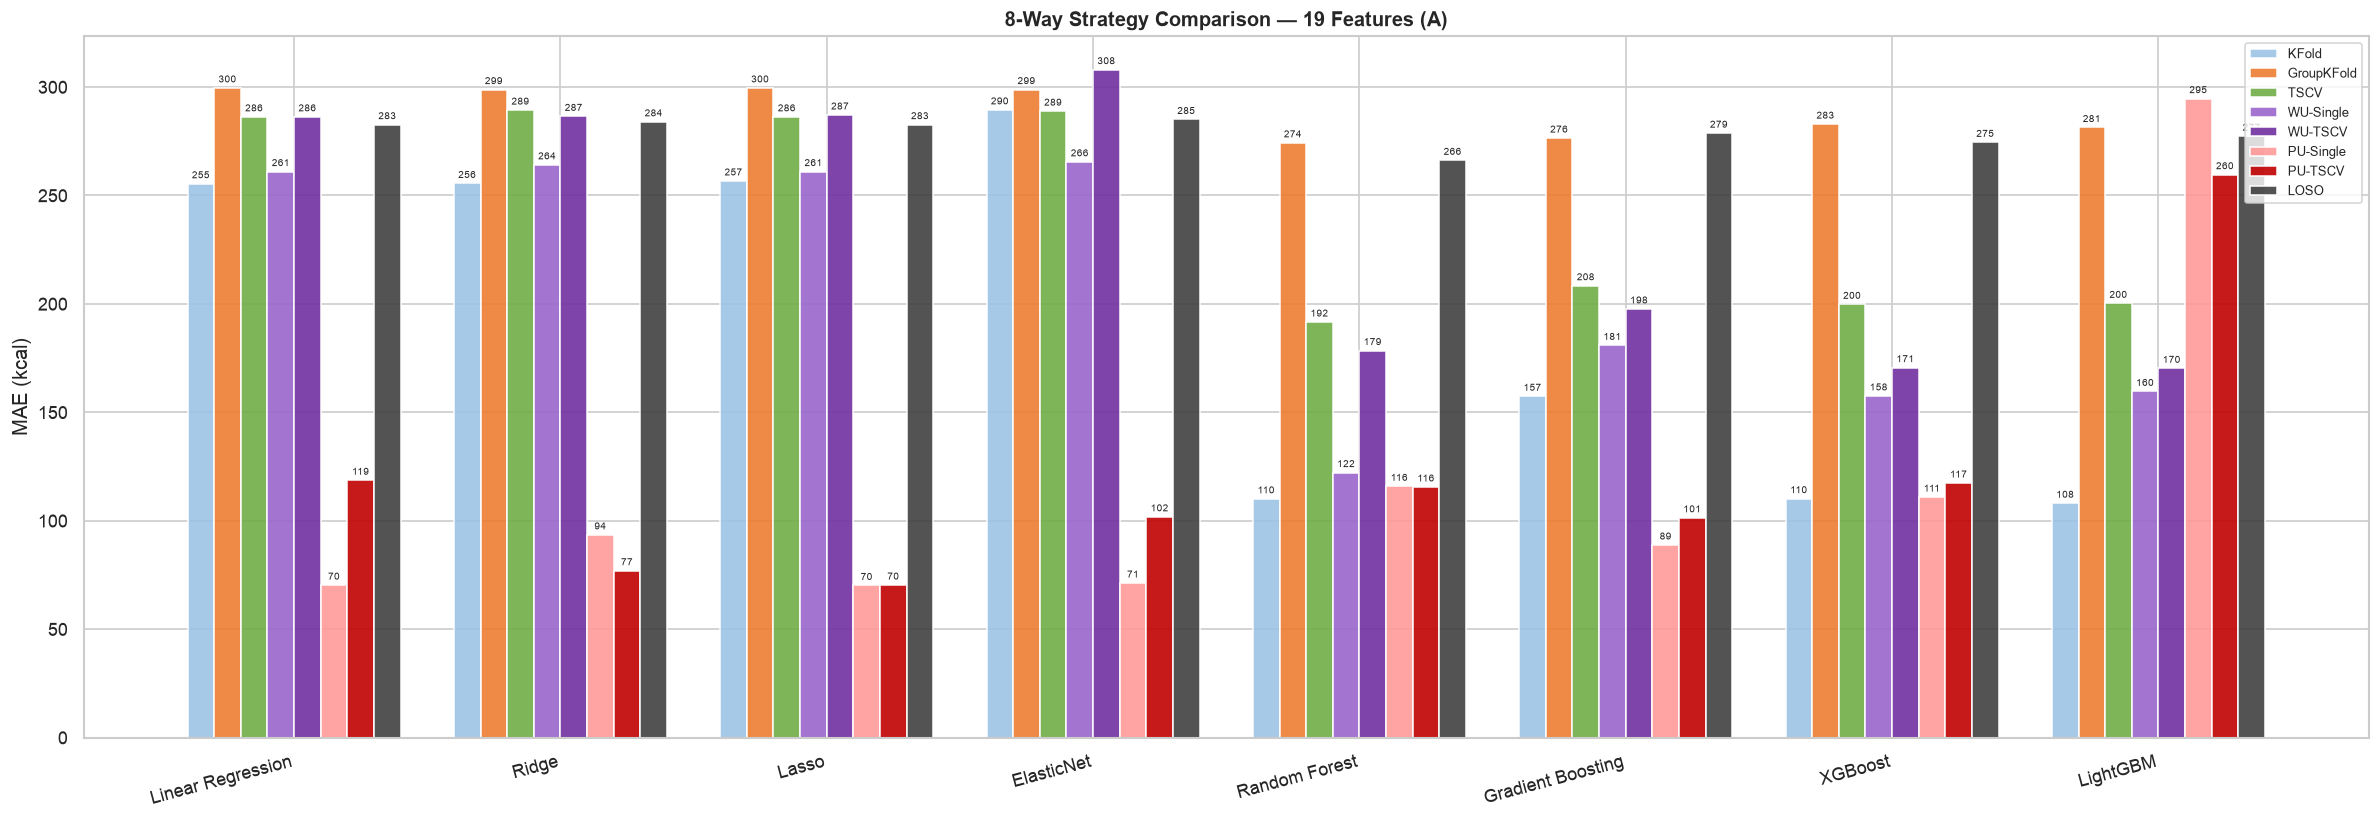

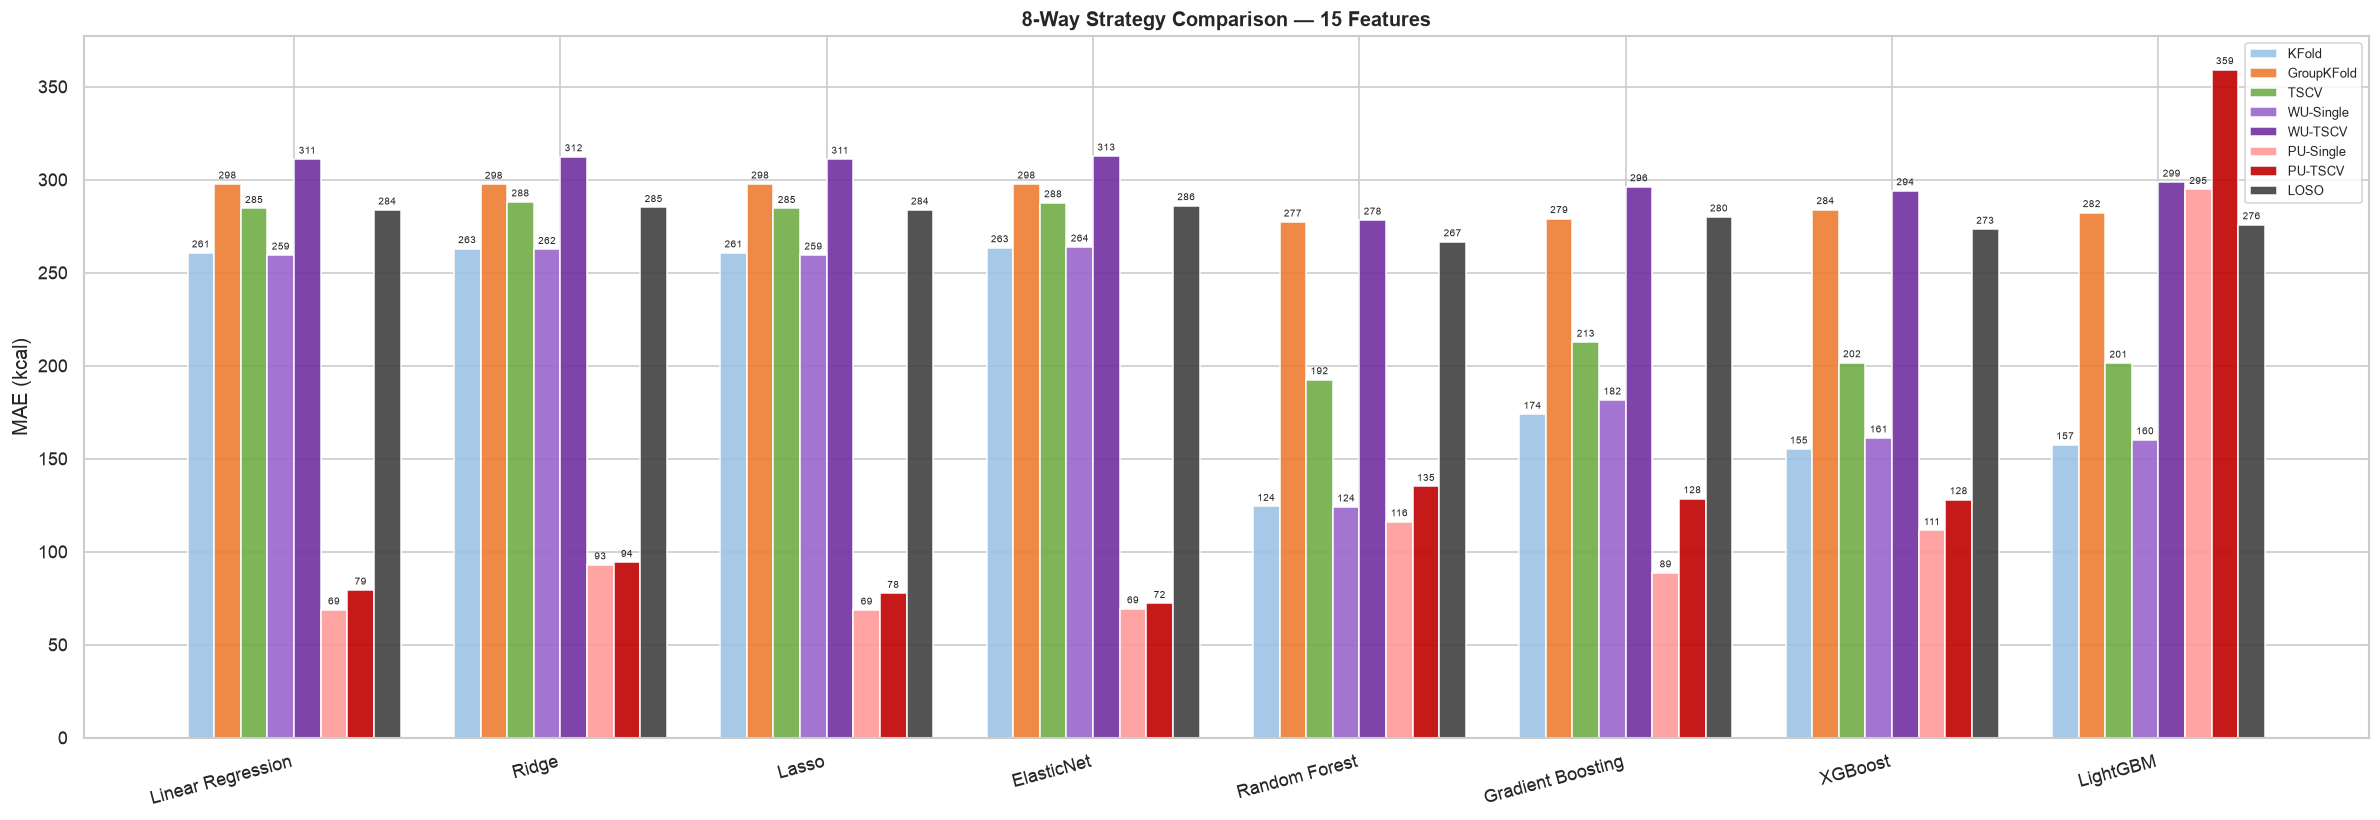

In [51]:
# ── 8-Way Strategy Comparison — 19 Features (A) ─────────────────────────────
strategies = ["KFold", "GroupKFold", "TSCV", "WU-Single", "WU-TSCV", "PU-Single", "PU-TSCV", "LOSO"]
colors     = ["#9DC3E6", "#ED7D31", "#70AD47", "#9966CC", "#7030A0", "#FF9999", "#C00000", "#404040"]

fig, ax = plt.subplots(figsize=(20, 7))
x = np.arange(len(df19)); width = 0.10
for i, (strat, color) in enumerate(zip(strategies, colors)):
    offset = (i - len(strategies) / 2 + 0.5) * width
    b = ax.bar(x + offset, df19[strat], width, label=strat, color=color, alpha=0.9)
    ax.bar_label(b, fmt="%.0f", padding=2, fontsize=6)
ax.set_xticks(x)
ax.set_xticklabels(df19.index, rotation=15, ha="right")
ax.set_ylabel("MAE (kcal)")
ax.set_title("8-Way Strategy Comparison — 19 Features (A)", fontweight="bold", fontsize=12)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

# ── 8-Way Strategy Comparison — 15 Features ─────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 7))
x = np.arange(len(df15)); width = 0.10
for i, (strat, color) in enumerate(zip(strategies, colors)):
    offset = (i - len(strategies) / 2 + 0.5) * width
    b = ax.bar(x + offset, df15[strat], width, label=strat, color=color, alpha=0.9)
    ax.bar_label(b, fmt="%.0f", padding=2, fontsize=6)
ax.set_xticks(x)
ax.set_xticklabels(df15.index, rotation=15, ha="right")
ax.set_ylabel("MAE (kcal)")
ax.set_title("8-Way Strategy Comparison — 15 Features", fontweight="bold", fontsize=12)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()


## 18. Save Best Models

> บันทึก model ที่ดีที่สุด (GKF-tuned) พร้อม full pipeline (imputer + scaler + model) ลงไฟล์ .joblib
> สามารถโหลดมาทำนายได้ทันทีโดยไม่ต้อง train ใหม่

In [41]:
import joblib, os, json as _json

# ── Directory for saved models ───────────────────────────────────────────────
MODELS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'saved_models') if 'notebooks' in os.getcwd() else 'saved_models'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Fit best tuned pipelines on ALL data and save ───────────────────────────
saved_info = {}

for name in default_models:
    pipe = make_pipe(get_gkf_tuned_model(name))
    pipe.fit(X, y)

    safe_name = name.lower().replace(" ", "_")
    filepath = os.path.join(MODELS_DIR, f"{safe_name}_gkf_tuned.joblib")
    joblib.dump(pipe, filepath)

    saved_info[name] = {
        "file": filepath,
        "gkf_mae": round(summary_df.loc[name, "GKF MAE (GKF-tuned)"], 2),
        "gkf_r2":  round(float(summary_df.loc[name, "GKF R²"]), 4),
    }
    print(f"Saved: {filepath}")

# ── Save feature list and metadata ──────────────────────────────────────────
meta = {
    "feature_cols": feature_cols,
    "target": "calories",
    "n_samples": len(y),
    "n_users": int(df["id"].nunique()),
    "cv_strategy": "GroupKFold (3 splits, grouped by user)",
    "models": saved_info,
}
meta_path = os.path.join(MODELS_DIR, "metadata.json")
with open(meta_path, "w") as f:
    _json.dump(meta, f, indent=2)
print(f"Saved metadata: {meta_path}")

# ── Summary ──────────────────────────────────────────────────────────────────
print()
print(f"=== Saved {len(saved_info)} models to: {MODELS_DIR} ===")
print(f"{'Model':<25} {'MAE (GKF)':>12} {'R² (GKF)':>10} {'File'}")
print("-" * 80)
for name, info in saved_info.items():
    fname = os.path.basename(info["file"])
    print(f"{name:<25} {info['gkf_mae']:>12.1f} {info['gkf_r2']:>10.4f}  {fname}")

Saved: /Users/thunthita/VISTEC/LifeSnaps/saved_models/linear_regression_gkf_tuned.joblib
Saved: /Users/thunthita/VISTEC/LifeSnaps/saved_models/ridge_gkf_tuned.joblib
Saved: /Users/thunthita/VISTEC/LifeSnaps/saved_models/lasso_gkf_tuned.joblib
Saved: /Users/thunthita/VISTEC/LifeSnaps/saved_models/elasticnet_gkf_tuned.joblib
Saved: /Users/thunthita/VISTEC/LifeSnaps/saved_models/random_forest_gkf_tuned.joblib
Saved: /Users/thunthita/VISTEC/LifeSnaps/saved_models/gradient_boosting_gkf_tuned.joblib
Saved: /Users/thunthita/VISTEC/LifeSnaps/saved_models/xgboost_gkf_tuned.joblib
Saved: /Users/thunthita/VISTEC/LifeSnaps/saved_models/lightgbm_gkf_tuned.joblib
Saved metadata: /Users/thunthita/VISTEC/LifeSnaps/saved_models/metadata.json

=== Saved 8 models to: /Users/thunthita/VISTEC/LifeSnaps/saved_models ===
Model                        MAE (GKF)   R² (GKF) File
--------------------------------------------------------------------------------
Linear Regression                299.6     0.6012  lin